# Design a Machine Learning Approach to Analyse Students’ Performance Based on Their Socio-economic Status in the Kingdom of Bahrain

**MSc Artificial Intelligence — Bahrain Polytechnic**  
**Student: Jaafar Ahmed | ID: 202508989**

# Phase 3 — Train/Test Split + Preprocessing Pipelines

## Experimental Design and Data Transformation

This phase receives the leakage-free structured modelling dataset from Phase 2, separates an untouched family-aware holdout test set, prepares family-aware cross-validation folds on the training set, defines the encoding and scaling strategies, creates reusable preprocessing-pipeline templates, analyses class imbalance, and exports the complete experimental design for Phase 4.

**Core methodological safeguards**

- Students from the same family must never appear in both training and test data.
- The holdout test set is reserved for final evaluation in Phase 8.
- Hyperparameter tuning and model comparison must use the training set and its cross-validation folds only.
- Preprocessing is placed inside model pipelines so that encoders and scalers are learned from each training fold only.
- Resampling, if later required, must occur inside training folds only.

## Phase 3 Folder Structure

```text
outputs/
└── Phase_03_Train_Test_Split_and_Preprocessing_Pipelines/
    └── Section_03_XX_Section_Title/
        └── Cell_03_XX_XX_Cell_Title/
            ├── tables/
            ├── figures/
            ├── reports/
            ├── models/
            └── files/
```

The final handoff includes the training set, untouched test set, cross-validation fold assignments, preprocessing templates, class-weight recommendations, evaluation configuration, and a manifest for Phase 4.

# Section 3.1 — Load Phase 2 Handoff

**Purpose:** Configure the execution environment, locate the Phase 2 modelling dataset and handoff manifest, and verify that the expected identifiers, predictors, group variable, and target are available.

In [1]:
# Cell 3.1.1 — Configure Environment, Project Folders, and Core Functions

from pathlib import Path
from datetime import datetime
import hashlib
import importlib
import importlib.util
import inspect
import json
import math
import os
import random
import re
import shutil
import subprocess
import sys
import warnings
import zipfile

# -----------------------------------------------------------------------------
# CHANGE THESE SETTINGS ONLY
# -----------------------------------------------------------------------------
EXECUTION_ENVIRONMENT = "COLAB"  # "COLAB", "ANACONDA", or "VSCODE"

# Optional portable overrides. Leave as None for automatic discovery.
PHASE_2_MANIFEST_OVERRIDE = None
PHASE_2_DATA_OVERRIDE = None

TEST_SIZE = 0.20
HOLDOUT_SPLIT_CANDIDATES = 5
CV_FOLDS = 5
AUTO_INSTALL_MISSING_PACKAGES = True
# -----------------------------------------------------------------------------

PROJECT_TITLE = (
    "Design a Machine Learning Approach to Analyse Students’ Performance "
    "Based on Their Socio-economic Status in the Kingdom of Bahrain"
)
PROGRAMME = "MSc Artificial Intelligence — Bahrain Polytechnic"
STUDENT_NAME = "Jaafar Ahmed"
STUDENT_ID = "202508989"

ALLOWED_ENVIRONMENTS = {"COLAB", "ANACONDA", "VSCODE"}
EXECUTION_ENVIRONMENT = EXECUTION_ENVIRONMENT.strip().upper()

if EXECUTION_ENVIRONMENT not in ALLOWED_ENVIRONMENTS:
    raise ValueError(
        f"EXECUTION_ENVIRONMENT must be one of {sorted(ALLOWED_ENVIRONMENTS)}"
    )

if EXECUTION_ENVIRONMENT == "COLAB":
    try:
        from google.colab import drive
        drive.mount("/content/drive")
        PROJECT_ROOT = Path("/content/drive/MyDrive/Jaafar_MSc_Thesis")
    except ImportError:
        print("Google Colab is unavailable; using the current directory.")
        PROJECT_ROOT = Path.cwd()
else:
    PROJECT_ROOT = Path.cwd()

DATA_DIR = PROJECT_ROOT / "data"
OUTPUT_ROOT = PROJECT_ROOT / "outputs"
PHASE_2_DIR = (
    OUTPUT_ROOT / "Phase_02_Data_Cleaning_and_Feature_Preparation"
)
PHASE_DIR = (
    OUTPUT_ROOT / "Phase_03_Train_Test_Split_and_Preprocessing_Pipelines"
)
SHARED_DIR = PROJECT_ROOT / "shared_project_files"

for folder in [DATA_DIR, OUTPUT_ROOT, PHASE_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

# Prefer the project-level shared folder. If it is not writable in the
# current runtime, use a portable Phase 3 subfolder automatically.
try:
    SHARED_DIR.mkdir(parents=True, exist_ok=True)
    permission_test_path = SHARED_DIR / ".phase_03_write_test"
    permission_test_path.write_text("test", encoding="utf-8")
    permission_test_path.unlink()
except (PermissionError, OSError):
    SHARED_DIR = PHASE_DIR / "shared_project_files"
    SHARED_DIR.mkdir(parents=True, exist_ok=True)
    print(
        "The project-level shared folder is not writable in this runtime. "
        "Using the Phase 3 portable shared folder instead:"
    )
    print(SHARED_DIR)

RANDOM_STATE = 42
RUN_TIMESTAMP = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
random.seed(RANDOM_STATE)


def safe_name(text):
    """Convert a title to a safe and readable folder/file name."""
    text = str(text).strip().replace("—", "-").replace("–", "-")
    text = re.sub(r"[^\w\-]+", "_", text, flags=re.UNICODE)
    return re.sub(r"_+", "_", text).strip("_") or "Unnamed"


def create_cell_folders(section_number, section_title, cell_number, cell_title):
    """Create the approved Phase → Section → Cell hierarchy."""
    section_folder = PHASE_DIR / safe_name(
        f"Section_{section_number}_{section_title}"
    )
    cell_folder = section_folder / safe_name(
        f"Cell_{cell_number}_{cell_title}"
    )
    folders = {
        "cell": cell_folder,
        "tables": cell_folder / "tables",
        "figures": cell_folder / "figures",
        "reports": cell_folder / "reports",
        "models": cell_folder / "models",
        "files": cell_folder / "files",
    }
    for folder in folders.values():
        folder.mkdir(parents=True, exist_ok=True)
    return folders


def save_dataframe(
    dataframe,
    folders,
    file_stem,
    save_csv=True,
    save_excel=True,
    index=False,
):
    """Save a DataFrame in CSV and Excel formats."""
    saved_paths = []

    if save_csv:
        csv_path = folders["tables"] / f"{file_stem}.csv"
        dataframe.to_csv(csv_path, index=index, encoding="utf-8-sig")
        saved_paths.append(csv_path)

    if save_excel:
        xlsx_path = folders["tables"] / f"{file_stem}.xlsx"
        dataframe.to_excel(xlsx_path, index=index)
        saved_paths.append(xlsx_path)

    return saved_paths


def save_json_report(data, folders, file_stem):
    """Save a structured JSON report."""
    path = folders["reports"] / f"{file_stem}.json"
    with path.open("w", encoding="utf-8") as file:
        json.dump(data, file, ensure_ascii=False, indent=2, default=str)
    return path


def sha256_file(path):
    """Calculate a SHA-256 hash for a file."""
    digest = hashlib.sha256()
    with Path(path).open("rb") as file:
        for block in iter(lambda: file.read(1024 * 1024), b""):
            digest.update(block)
    return digest.hexdigest()


def load_table(path):
    """Load a CSV or Excel table."""
    path = Path(path)
    if path.suffix.lower() == ".csv":
        try:
            return pd.read_csv(path, encoding="utf-8-sig")
        except UnicodeDecodeError:
            return pd.read_csv(path, encoding="latin-1")
    if path.suffix.lower() in {".xlsx", ".xls"}:
        return pd.read_excel(path)
    raise ValueError(f"Unsupported table format: {path.suffix}")


CELL_FOLDERS = create_cell_folders(
    "03_01",
    "Load_Phase_2_Handoff",
    "03_01_01",
    "Configure_Environment_Project_Folders_and_Core_Functions",
)

project_configuration = {
    "project_title": PROJECT_TITLE,
    "programme": PROGRAMME,
    "student_name": STUDENT_NAME,
    "student_id": STUDENT_ID,
    "execution_environment": EXECUTION_ENVIRONMENT,
    "project_root": str(PROJECT_ROOT),
    "data_directory": str(DATA_DIR),
    "phase_2_directory": str(PHASE_2_DIR),
    "phase_3_directory": str(PHASE_DIR),
    "test_size": TEST_SIZE,
    "holdout_split_candidates": HOLDOUT_SPLIT_CANDIDATES,
    "cv_folds": CV_FOLDS,
    "random_state": RANDOM_STATE,
    "run_timestamp": RUN_TIMESTAMP,
}

save_json_report(
    project_configuration,
    CELL_FOLDERS,
    "03_01_01_project_configuration",
)

print("Execution environment:", EXECUTION_ENVIRONMENT)
print("Project root:", PROJECT_ROOT)
print("Phase 2 directory:", PHASE_2_DIR)
print("Phase 3 directory:", PHASE_DIR)

Google Colab is unavailable; using the current directory.
Execution environment: COLAB
Project root: C:\Users\User\Desktop\All
Phase 2 directory: C:\Users\User\Desktop\All\outputs\Phase_02_Data_Cleaning_and_Feature_Preparation
Phase 3 directory: C:\Users\User\Desktop\All\outputs\Phase_03_Train_Test_Split_and_Preprocessing_Pipelines


In [2]:
# Cell 3.1.2 — Check Libraries and Define the Bahrain Thesis Visual Identity

required_packages = {
    "pandas": "pandas",
    "numpy": "numpy",
    "matplotlib": "matplotlib",
    "scipy": "scipy",
    "sklearn": "scikit-learn",
    "joblib": "joblib",
    "openpyxl": "openpyxl",
}

installation_rows = []

for import_name, package_name in required_packages.items():
    installed = importlib.util.find_spec(import_name) is not None

    if installed:
        status = "Already installed"
    elif AUTO_INSTALL_MISSING_PACKAGES:
        subprocess.check_call(
            [sys.executable, "-m", "pip", "install", package_name]
        )
        status = "Installed during this run"
    else:
        raise ImportError(
            f"Missing package: {package_name}. "
            "Enable AUTO_INSTALL_MISSING_PACKAGES or install it manually."
        )

    installation_rows.append(
        {
            "import_name": import_name,
            "package_name": package_name,
            "status": status,
        }
    )

import joblib
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import numpy as np
import pandas as pd
import sklearn
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    OneHotEncoder,
    OrdinalEncoder,
    StandardScaler,
)
from sklearn.utils.class_weight import compute_class_weight

warnings.filterwarnings("default")
np.random.seed(RANDOM_STATE)

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 120)
pd.set_option("display.width", 190)

THEME = {
    "maroon": "#6B1E32",
    "deep_maroon": "#43101F",
    "gold": "#D4A64A",
    "teal": "#237A7A",
    "coral": "#D96850",
    "indigo": "#525B92",
    "sage": "#7A9B76",
    "sand": "#D9C7A3",
    "warm_white": "#F7F4EF",
    "charcoal": "#2E3035",
    "soft_grey": "#D8D5D0",
    "light_maroon": "#B77987",
}

CLASS_COLORS = {
    "Low": THEME["coral"],
    "Medium": THEME["gold"],
    "High": THEME["teal"],
}

PALETTE = [
    THEME["maroon"],
    THEME["gold"],
    THEME["teal"],
    THEME["coral"],
    THEME["indigo"],
    THEME["sage"],
    THEME["sand"],
]

mpl.rcParams.update(
    {
        "figure.facecolor": THEME["warm_white"],
        "axes.facecolor": THEME["warm_white"],
        "savefig.facecolor": THEME["warm_white"],
        "axes.edgecolor": THEME["charcoal"],
        "axes.labelcolor": THEME["charcoal"],
        "text.color": THEME["charcoal"],
        "xtick.color": THEME["charcoal"],
        "ytick.color": THEME["charcoal"],
        "font.size": 10,
        "axes.titleweight": "bold",
        "axes.titlesize": 15,
        "axes.labelsize": 11,
        "legend.frameon": False,
    }
)


def style_axis(axis, title, subtitle=None, grid_axis="y"):
    """Apply the project visual identity to one chart."""
    axis.set_title(title, loc="left", pad=18, fontweight="bold")
    if subtitle:
        axis.text(
            0,
            1.015,
            subtitle,
            transform=axis.transAxes,
            fontsize=9,
            color="#5B5B5B",
            va="bottom",
        )
    axis.spines["top"].set_visible(False)
    axis.spines["right"].set_visible(False)
    axis.spines["left"].set_alpha(0.35)
    axis.spines["bottom"].set_alpha(0.35)
    if grid_axis:
        axis.grid(axis=grid_axis, alpha=0.16, linewidth=0.8)
    axis.set_axisbelow(True)


def add_figure_footer(figure, text=None):
    footer = text or (
        "MSc Artificial Intelligence — Bahrain Polytechnic | "
        "Phase 3: Train/Test Split + Preprocessing Pipelines"
    )
    figure.text(
        0.01,
        0.01,
        footer,
        fontsize=7.5,
        color="#6A6A6A",
        ha="left",
    )


def save_figure(figure, folders, file_stem):
    path = folders["figures"] / f"{file_stem}.png"
    figure.savefig(path, dpi=300, bbox_inches="tight")
    return path


CELL_FOLDERS = create_cell_folders(
    "03_01",
    "Load_Phase_2_Handoff",
    "03_01_02",
    "Check_Libraries_and_Define_the_Bahrain_Thesis_Visual_Identity",
)

installation_report = pd.DataFrame(installation_rows)
library_versions = pd.DataFrame(
    [
        ["Python", sys.version.split()[0]],
        ["pandas", pd.__version__],
        ["numpy", np.__version__],
        ["matplotlib", mpl.__version__],
        ["scikit-learn", sklearn.__version__],
        ["joblib", joblib.__version__],
    ],
    columns=["library", "version"],
)

save_dataframe(
    installation_report,
    CELL_FOLDERS,
    "03_01_02_library_installation_report",
)
save_dataframe(
    library_versions,
    CELL_FOLDERS,
    "03_01_02_library_versions",
)
save_json_report(THEME, CELL_FOLDERS, "03_01_02_visual_theme")

display(installation_report)
display(library_versions)

,import_name,package_name,status
0,pandas,pandas,Already installed
1,numpy,numpy,Already installed
2,matplotlib,matplotlib,Already installed
3,scipy,scipy,Already installed
4,sklearn,scikit-learn,Already installed
5,joblib,joblib,Already installed
6,openpyxl,openpyxl,Already installed


,library,version
0,Python,3.13.5
1,pandas,2.2.3
2,numpy,2.1.3
3,matplotlib,3.10.0
4,scikit-learn,1.6.1
5,joblib,1.4.2


In [3]:
# Cell 3.1.3 — Locate the Phase 2 Manifest and Load the Modelling Dataset

CELL_FOLDERS = create_cell_folders(
    "03_01",
    "Load_Phase_2_Handoff",
    "03_01_03",
    "Locate_Phase_2_Manifest_and_Load_the_Modelling_Dataset",
)


def locate_phase_2_manifest():
    """Locate the Phase 2 handoff manifest for Phase 3."""
    candidates = []

    if PHASE_2_MANIFEST_OVERRIDE is not None:
        candidates.append(Path(PHASE_2_MANIFEST_OVERRIDE).expanduser())

    candidates.extend(
        [
            PHASE_2_DIR / "phase_02_handoff_manifest_for_phase_03.json",
            OUTPUT_ROOT / "phase_02_handoff_manifest_for_phase_03.json",
            PROJECT_ROOT / "phase_02_handoff_manifest_for_phase_03.json",
            Path.cwd() / "phase_02_handoff_manifest_for_phase_03.json",
        ]
    )

    if PHASE_2_DIR.exists():
        candidates.extend(
            PHASE_2_DIR.rglob(
                "phase_02_handoff_manifest_for_phase_03.json"
            )
        )

    for candidate in candidates:
        if Path(candidate).exists():
            return Path(candidate)

    return None


def resolve_phase_2_dataset(manifest):
    """Resolve the portable Phase 2 modelling dataset."""
    if PHASE_2_DATA_OVERRIDE is not None:
        override = Path(PHASE_2_DATA_OVERRIDE).expanduser()
        if override.exists():
            return override
        raise FileNotFoundError(f"PHASE_2_DATA_OVERRIDE not found: {override}")

    recorded_path = manifest.get("primary_input_for_phase_3")
    if recorded_path and Path(recorded_path).exists():
        return Path(recorded_path)

    portable_candidates = [
        DATA_DIR / "phase_02_modelling_dataset_for_phase_03.csv",
        DATA_DIR / "phase_02_modelling_dataset_for_phase_03.xlsx",
        PROJECT_ROOT / "phase_02_modelling_dataset_for_phase_03.csv",
        Path.cwd() / "data" / "phase_02_modelling_dataset_for_phase_03.csv",
        Path.cwd() / "phase_02_modelling_dataset_for_phase_03.csv",
    ]

    if PHASE_2_DIR.exists():
        portable_candidates.extend(
            PHASE_2_DIR.rglob(
                "phase_02_modelling_dataset_for_phase_03.csv"
            )
        )
        portable_candidates.extend(
            PHASE_2_DIR.rglob(
                "phase_02_modelling_dataset_for_phase_03.xlsx"
            )
        )

    for candidate in portable_candidates:
        if Path(candidate).exists():
            return Path(candidate)

    raise FileNotFoundError(
        "The Phase 2 modelling dataset was not found. Run Phase 2 first "
        "or set PHASE_2_DATA_OVERRIDE."
    )


PHASE_2_MANIFEST_PATH = locate_phase_2_manifest()

if PHASE_2_MANIFEST_PATH is not None:
    with PHASE_2_MANIFEST_PATH.open("r", encoding="utf-8") as file:
        phase_2_manifest = json.load(file)
else:
    phase_2_manifest = {}

PHASE_2_DATA_PATH = resolve_phase_2_dataset(phase_2_manifest)
modelling_data = load_table(PHASE_2_DATA_PATH)

if modelling_data.empty:
    raise ValueError("The Phase 2 modelling dataset is empty.")

INPUT_FILE_SHA256 = sha256_file(PHASE_2_DATA_PATH)

loading_summary = {
    "phase_2_manifest": (
        str(PHASE_2_MANIFEST_PATH)
        if PHASE_2_MANIFEST_PATH is not None
        else None
    ),
    "phase_2_dataset": str(PHASE_2_DATA_PATH),
    "input_sha256": INPUT_FILE_SHA256,
    "rows": int(modelling_data.shape[0]),
    "columns": int(modelling_data.shape[1]),
    "loaded_at": datetime.now().isoformat(),
}

save_json_report(
    loading_summary,
    CELL_FOLDERS,
    "03_01_03_phase_2_loading_summary",
)

data_preview = pd.concat(
    [
        modelling_data.head(5).assign(preview_location="First records"),
        modelling_data.tail(5).assign(preview_location="Last records"),
    ],
    ignore_index=True,
)
save_dataframe(
    data_preview,
    CELL_FOLDERS,
    "03_01_03_modelling_dataset_preview",
)

print("Phase 2 manifest:", PHASE_2_MANIFEST_PATH)
print("Phase 2 dataset:", PHASE_2_DATA_PATH)
print("Input SHA-256:", INPUT_FILE_SHA256)
print("Dataset shape:", modelling_data.shape)
display(data_preview)

Phase 2 manifest: C:\Users\User\Desktop\All\outputs\Phase_02_Data_Cleaning_and_Feature_Preparation\phase_02_handoff_manifest_for_phase_03.json
Phase 2 dataset: C:\Users\User\Desktop\All\data\phase_02_modelling_dataset_for_phase_03.csv
Input SHA-256: 48980d7fa7d2add410727ea9cbcf45773f578b02b38549ad1284d36109a15b0d
Dataset shape: (2500, 20)


,student_record_id,family_id,father_alive,mother_alive,father_education,mother_education,father_job,mother_job,marital_status,family_income,number_of_children,gender,school_type,stage,overall_grade_level,tutoring_support,social_activities,chronic_disease,daily_smart_device_usage,academic_performance_class,preview_location
0,STU000001,1,Yes,Yes,Bachelor's,Bachelor's,Employed,Employed,Married,More than 1000 BHD,3,Female,Private,Primary,1,No,Yes,No,1 - 3 hours,High,First records
1,STU000002,1,Yes,Yes,Bachelor's,Bachelor's,Employed,Employed,Married,More than 1000 BHD,3,Male,Private,Primary,6,Yes,Yes,No,Less than an hour,High,First records
2,STU000003,1,Yes,Yes,Bachelor's,Bachelor's,Employed,Employed,Married,More than 1000 BHD,3,Male,Government,Secondary,12,Yes,No,No,More than 5 hours,High,First records
3,STU000004,2,Yes,Yes,Secondary,Bachelor's,Employed,Retired,Married,700 – 1000 BHD,2,Female,Government,Primary,1,Yes,Yes,No,3 - 5 hours,High,First records
4,STU000005,2,Yes,Yes,Secondary,Bachelor's,Employed,Retired,Married,700 – 1000 BHD,2,Male,Government,Primary,4,Yes,Yes,No,1 - 3 hours,Low,First records
5,STU002496,1234,Yes,No,Diploma,Diploma,Employed,Employed,Widower,300 – 700 BHD,4,Female,Government,Primary,1,Yes,Yes,No,3 - 5 hours,High,Last records
6,STU002497,1235,Yes,Yes,Intermediate,Diploma,Employed,Unemployed,Married,300 – 700 BHD,4,Male,Government,Intermediate,9,Yes,Yes,No,3 - 5 hours,Medium,Last records
7,STU002498,1236,Yes,Yes,Diploma,Bachelor's,Employed,Unemployed,Married,700 – 1000 BHD,2,Female,Government,Primary,3,No,Yes,Yes,Less than an hour,High,Last records
8,STU002499,1237,Yes,Yes,Bachelor's,Bachelor's,Employed,Employed,Married,More than 1000 BHD,4,Male,Government,Primary,3,Yes,Yes,No,1 - 3 hours,High,Last records
9,STU002500,1238,Yes,Yes,Bachelor's,Bachelor's,Employed,Employed,Married,700 – 1000 BHD,4,Female,Government,Intermediate,7,Yes,No,No,3 - 5 hours,Medium,Last records


# Section 3.2 — Define Predictors, Target, and Group Variable

**Purpose:** Reconstruct the modelling roles from the Phase 2 manifest, verify the exact predictor schema, and separate identifiers from model inputs.

In [4]:
# Cell 3.2.1 — Define and Validate X, y, Groups, and Record IDs

CELL_FOLDERS = create_cell_folders(
    "03_02",
    "Define_Predictors_Target_and_Group_Variable",
    "03_02_01",
    "Define_and_Validate_X_y_Groups_and_Record_IDs",
)

ID_COLUMN = "student_record_id"
GROUP_COLUMN = phase_2_manifest.get("group_column", "family_id")
TARGET_COLUMN = phase_2_manifest.get(
    "target_column",
    "academic_performance_class",
)

DEFAULT_PREDICTOR_COLUMNS = [
    "father_alive",
    "mother_alive",
    "father_education",
    "mother_education",
    "father_job",
    "mother_job",
    "marital_status",
    "family_income",
    "number_of_children",
    "gender",
    "school_type",
    "stage",
    "overall_grade_level",
    "tutoring_support",
    "social_activities",
    "chronic_disease",
    "daily_smart_device_usage",
]

PREDICTOR_COLUMNS = phase_2_manifest.get(
    "predictor_columns",
    DEFAULT_PREDICTOR_COLUMNS,
)

required_columns = [
    ID_COLUMN,
    GROUP_COLUMN,
    *PREDICTOR_COLUMNS,
    TARGET_COLUMN,
]

missing_columns = sorted(
    set(required_columns) - set(modelling_data.columns)
)

if missing_columns:
    raise ValueError(
        "The Phase 2 modelling dataset is missing required columns: "
        + ", ".join(missing_columns)
    )

if modelling_data[ID_COLUMN].duplicated().any():
    raise ValueError("student_record_id must be unique.")

if modelling_data[GROUP_COLUMN].isna().any():
    raise ValueError("family_id cannot be missing before grouped splitting.")

if modelling_data[TARGET_COLUMN].isna().any():
    raise ValueError("The target cannot be missing before splitting.")

X = modelling_data[PREDICTOR_COLUMNS].copy()
y = modelling_data[TARGET_COLUMN].astype(str).copy()
groups = modelling_data[GROUP_COLUMN].copy()
record_ids = modelling_data[ID_COLUMN].astype(str).copy()

TARGET_CLASSES = ["Low", "Medium", "High"]

observed_classes = set(y.unique())
if observed_classes != set(TARGET_CLASSES):
    raise ValueError(
        f"Expected target classes {TARGET_CLASSES}; observed "
        f"{sorted(observed_classes)}"
    )

role_table = pd.DataFrame(
    [
        {
            "variable": column,
            "role": (
                "Identifier"
                if column == ID_COLUMN
                else "Group variable"
                if column == GROUP_COLUMN
                else "Target"
                if column == TARGET_COLUMN
                else "Predictor"
            ),
            "used_as_predictor": column in PREDICTOR_COLUMNS,
        }
        for column in required_columns
    ]
)

dataset_role_summary = pd.DataFrame(
    [
        ["Records", len(modelling_data)],
        ["Predictors", len(PREDICTOR_COLUMNS)],
        ["Unique families", groups.nunique()],
        ["Target classes", y.nunique()],
        ["Missing predictor cells", int(X.isna().sum().sum())],
    ],
    columns=["role_measure", "value"],
)

save_dataframe(
    role_table,
    CELL_FOLDERS,
    "03_02_01_variable_roles",
)
save_dataframe(
    dataset_role_summary,
    CELL_FOLDERS,
    "03_02_01_dataset_role_summary",
)
save_json_report(
    {
        "identifier_column": ID_COLUMN,
        "group_column": GROUP_COLUMN,
        "target_column": TARGET_COLUMN,
        "predictor_columns": PREDICTOR_COLUMNS,
        "target_classes": TARGET_CLASSES,
    },
    CELL_FOLDERS,
    "03_02_01_modelling_roles",
)

display(dataset_role_summary)
display(role_table)

,role_measure,value
0,Records,2500
1,Predictors,17
2,Unique families,1238
3,Target classes,3
4,Missing predictor cells,0


,variable,role,used_as_predictor
0,student_record_id,Identifier,False
1,family_id,Group variable,False
2,father_alive,Predictor,True
3,mother_alive,Predictor,True
4,father_education,Predictor,True
5,mother_education,Predictor,True
6,father_job,Predictor,True
7,mother_job,Predictor,True
8,marital_status,Predictor,True
9,family_income,Predictor,True


# Section 3.3 — Stratified Group Train/Test Split

**Purpose:** Reserve approximately 20% of the records as a family-independent holdout test set. Candidate folds are compared only by split size and target-distribution preservation.

In [5]:
# Cell 3.3.1 — Generate and Select the Best Stratified Group Holdout Fold

CELL_FOLDERS = create_cell_folders(
    "03_03",
    "Stratified_Group_Train_Test_Split",
    "03_03_01",
    "Generate_and_Select_the_Best_Stratified_Group_Holdout_Fold",
)

if not math.isclose(
    TEST_SIZE,
    1 / HOLDOUT_SPLIT_CANDIDATES,
    rel_tol=0.20,
    abs_tol=0.03,
):
    print(
        "Note: TEST_SIZE is approximated using "
        f"{HOLDOUT_SPLIT_CANDIDATES} StratifiedGroupKFold candidates."
    )

holdout_splitter = StratifiedGroupKFold(
    n_splits=HOLDOUT_SPLIT_CANDIDATES,
    shuffle=True,
    random_state=RANDOM_STATE,
)

overall_distribution = (
    y.value_counts(normalize=True)
    .reindex(TARGET_CLASSES, fill_value=0)
)

candidate_rows = []
candidate_splits = []

for candidate_number, (train_indices, test_indices) in enumerate(
    holdout_splitter.split(X, y, groups),
    start=1,
):
    y_candidate_train = y.iloc[train_indices]
    y_candidate_test = y.iloc[test_indices]

    train_groups = set(groups.iloc[train_indices])
    test_groups = set(groups.iloc[test_indices])
    group_overlap = train_groups.intersection(test_groups)

    test_distribution = (
        y_candidate_test.value_counts(normalize=True)
        .reindex(TARGET_CLASSES, fill_value=0)
    )

    test_fraction = len(test_indices) / len(X)
    size_error = abs(test_fraction - TEST_SIZE)
    distribution_error = float(
        np.abs(test_distribution - overall_distribution).sum()
    )

    objective_score = size_error + distribution_error

    candidate_rows.append(
        {
            "candidate_fold": candidate_number,
            "train_records": len(train_indices),
            "test_records": len(test_indices),
            "test_fraction": round(test_fraction, 6),
            "size_error": round(size_error, 6),
            "distribution_error_l1": round(distribution_error, 6),
            "objective_score": round(objective_score, 6),
            "train_families": len(train_groups),
            "test_families": len(test_groups),
            "family_overlap": len(group_overlap),
            "test_low_pct": round(
                test_distribution["Low"] * 100,
                3,
            ),
            "test_medium_pct": round(
                test_distribution["Medium"] * 100,
                3,
            ),
            "test_high_pct": round(
                test_distribution["High"] * 100,
                3,
            ),
        }
    )
    candidate_splits.append((train_indices, test_indices))

holdout_candidate_table = pd.DataFrame(candidate_rows)
best_candidate_index = holdout_candidate_table[
    "objective_score"
].idxmin()
best_candidate_row = holdout_candidate_table.loc[best_candidate_index]
selected_candidate_number = int(best_candidate_row["candidate_fold"])

train_indices, test_indices = candidate_splits[
    selected_candidate_number - 1
]

X_train = X.iloc[train_indices].reset_index(drop=True)
X_test = X.iloc[test_indices].reset_index(drop=True)

y_train = y.iloc[train_indices].reset_index(drop=True)
y_test = y.iloc[test_indices].reset_index(drop=True)

groups_train = groups.iloc[train_indices].reset_index(drop=True)
groups_test = groups.iloc[test_indices].reset_index(drop=True)

record_ids_train = record_ids.iloc[train_indices].reset_index(drop=True)
record_ids_test = record_ids.iloc[test_indices].reset_index(drop=True)

split_label = pd.Series("Train", index=modelling_data.index)
split_label.iloc[test_indices] = "Test"

holdout_assignment = pd.DataFrame(
    {
        ID_COLUMN: record_ids,
        GROUP_COLUMN: groups,
        TARGET_COLUMN: y,
        "dataset_split": split_label,
    }
).sort_values(["dataset_split", GROUP_COLUMN, ID_COLUMN])

save_dataframe(
    holdout_candidate_table,
    CELL_FOLDERS,
    "03_03_01_holdout_candidate_comparison",
)
save_dataframe(
    holdout_assignment,
    CELL_FOLDERS,
    "03_03_01_holdout_split_assignment",
)

print("Selected candidate fold:", selected_candidate_number)
display(
    holdout_candidate_table.style.format(
        {
            "test_fraction": "{:.3f}",
            "objective_score": "{:.4f}",
        }
    )
)

Selected candidate fold: 3


,candidate_fold,train_records,test_records,test_fraction,size_error,distribution_error_l1,objective_score,train_families,test_families,family_overlap,test_low_pct,test_medium_pct,test_high_pct
0,1,1978,522,0.209,0.008800,0.068966,0.0778,988,250,0,22.797000,53.448000,23.755000
1,2,2002,498,0.199,0.000800,0.078313,0.0791,992,246,0,28.916000,47.189000,23.896000
2,3,2006,494,0.198,0.002400,0.040486,0.0429,984,254,0,23.279000,52.024000,24.696000
3,4,2016,484,0.194,0.006400,0.095041,0.1014,992,246,0,22.107000,48.140000,29.752000
4,5,1998,502,0.201,0.000800,0.057769,0.0586,996,242,0,27.888000,49.004000,23.108000


In [6]:
# Cell 3.3.2 — Validate Family Isolation and Target Distribution

CELL_FOLDERS = create_cell_folders(
    "03_03",
    "Stratified_Group_Train_Test_Split",
    "03_03_02",
    "Validate_Family_Isolation_and_Target_Distribution",
)

train_family_set = set(groups_train)
test_family_set = set(groups_test)
family_overlap = train_family_set.intersection(test_family_set)

split_distribution_rows = []

for split_name, split_target in [
    ("Full dataset", y),
    ("Training set", y_train),
    ("Holdout test set", y_test),
]:
    counts = (
        split_target.value_counts()
        .reindex(TARGET_CLASSES, fill_value=0)
    )
    percentages = counts / len(split_target) * 100

    for class_name in TARGET_CLASSES:
        split_distribution_rows.append(
            {
                "dataset_split": split_name,
                "academic_performance_class": class_name,
                "record_count": int(counts[class_name]),
                "percentage": round(
                    percentages[class_name],
                    3,
                ),
            }
        )

split_distribution = pd.DataFrame(split_distribution_rows)

holdout_validation = pd.DataFrame(
    [
        [
            "Training records",
            len(X_train),
            True,
        ],
        [
            "Holdout test records",
            len(X_test),
            True,
        ],
        [
            "Holdout test fraction",
            round(len(X_test) / len(X), 4),
            abs(len(X_test) / len(X) - TEST_SIZE) <= 0.03,
        ],
        [
            "Training families",
            groups_train.nunique(),
            True,
        ],
        [
            "Holdout test families",
            groups_test.nunique(),
            True,
        ],
        [
            "Families appearing in both sets",
            len(family_overlap),
            len(family_overlap) == 0,
        ],
        [
            "All classes available in training",
            y_train.nunique(),
            set(y_train.unique()) == set(TARGET_CLASSES),
        ],
        [
            "All classes available in holdout test",
            y_test.nunique(),
            set(y_test.unique()) == set(TARGET_CLASSES),
        ],
        [
            "Records lost or duplicated",
            len(X_train) + len(X_test) - len(X),
            len(X_train) + len(X_test) == len(X),
        ],
    ],
    columns=["validation_check", "value", "passed"],
)

save_dataframe(
    split_distribution,
    CELL_FOLDERS,
    "03_03_02_split_target_distribution",
)
save_dataframe(
    holdout_validation,
    CELL_FOLDERS,
    "03_03_02_holdout_validation",
)

display(holdout_validation)
display(split_distribution)

if not holdout_validation["passed"].all():
    failed_checks = holdout_validation.loc[
        ~holdout_validation["passed"],
        "validation_check",
    ].tolist()
    raise AssertionError(
        "Holdout split validation failed: " + "; ".join(failed_checks)
    )

,validation_check,value,passed
0,Training records,2006.0000,True
1,Holdout test records,494.0000,True
2,Holdout test fraction,0.1976,True
3,Training families,984.0000,True
4,Holdout test families,254.0000,True
5,Families appearing in both sets,0.0000,True
6,All classes available in training,3.0000,True
7,All classes available in holdout test,3.0000,True
8,Records lost or duplicated,0.0000,True


,dataset_split,academic_performance_class,record_count,percentage
0,Full dataset,Low,625,25.000
1,Full dataset,Medium,1250,50.000
2,Full dataset,High,625,25.000
3,Training set,Low,510,25.424
4,Training set,Medium,993,49.501
5,Training set,High,503,25.075
6,Holdout test set,Low,115,23.279
7,Holdout test set,Medium,257,52.024
8,Holdout test set,High,122,24.696


# Section 3.4 — Cross-Validation Strategy

**Purpose:** Create five family-independent stratified validation folds within the training set. The holdout test set is excluded from this process.

In [7]:
# Cell 3.4.1 — Create Stratified Group Cross-Validation Folds on Training Data

CELL_FOLDERS = create_cell_folders(
    "03_04",
    "Cross_Validation_Strategy",
    "03_04_01",
    "Create_Stratified_Group_Cross_Validation_Folds_on_Training_Data",
)

cross_validator = StratifiedGroupKFold(
    n_splits=CV_FOLDS,
    shuffle=True,
    random_state=RANDOM_STATE,
)

cv_assignment = pd.DataFrame(
    {
        ID_COLUMN: record_ids_train,
        GROUP_COLUMN: groups_train,
        TARGET_COLUMN: y_train,
        "validation_fold": pd.NA,
    }
)

cv_fold_summary_rows = []
cv_validation_rows = []

for fold_number, (fold_train_indices, fold_validation_indices) in enumerate(
    cross_validator.split(X_train, y_train, groups_train),
    start=1,
):
    cv_assignment.loc[
        fold_validation_indices,
        "validation_fold",
    ] = fold_number

    fold_train_groups = set(groups_train.iloc[fold_train_indices])
    fold_validation_groups = set(
        groups_train.iloc[fold_validation_indices]
    )
    fold_overlap = fold_train_groups.intersection(fold_validation_groups)

    fold_train_target = y_train.iloc[fold_train_indices]
    fold_validation_target = y_train.iloc[fold_validation_indices]

    validation_distribution = (
        fold_validation_target.value_counts(normalize=True)
        .reindex(TARGET_CLASSES, fill_value=0)
    )

    cv_fold_summary_rows.append(
        {
            "fold": fold_number,
            "training_records": len(fold_train_indices),
            "validation_records": len(fold_validation_indices),
            "training_families": len(fold_train_groups),
            "validation_families": len(fold_validation_groups),
            "family_overlap": len(fold_overlap),
            "validation_low_pct": round(
                validation_distribution["Low"] * 100,
                3,
            ),
            "validation_medium_pct": round(
                validation_distribution["Medium"] * 100,
                3,
            ),
            "validation_high_pct": round(
                validation_distribution["High"] * 100,
                3,
            ),
        }
    )

    cv_validation_rows.append(
        {
            "fold": fold_number,
            "family_overlap_is_zero": len(fold_overlap) == 0,
            "all_classes_in_training": (
                set(fold_train_target.unique()) == set(TARGET_CLASSES)
            ),
            "all_classes_in_validation": (
                set(fold_validation_target.unique()) == set(TARGET_CLASSES)
            ),
        }
    )

cv_assignment["validation_fold"] = cv_assignment[
    "validation_fold"
].astype("Int64")

cv_fold_summary = pd.DataFrame(cv_fold_summary_rows)
cv_validation = pd.DataFrame(cv_validation_rows)

if cv_assignment["validation_fold"].isna().any():
    raise AssertionError(
        "Every training record must be assigned to one validation fold."
    )

save_dataframe(
    cv_assignment,
    CELL_FOLDERS,
    "03_04_01_cross_validation_fold_assignment",
)
save_dataframe(
    cv_fold_summary,
    CELL_FOLDERS,
    "03_04_01_cross_validation_fold_summary",
)
save_dataframe(
    cv_validation,
    CELL_FOLDERS,
    "03_04_01_cross_validation_validation",
)

display(cv_fold_summary)
display(cv_validation)

if not cv_validation.drop(columns="fold").all(axis=None):
    raise AssertionError(
        "One or more cross-validation fold checks failed."
    )

,fold,training_records,validation_records,training_families,validation_families,family_overlap,validation_low_pct,validation_medium_pct,validation_high_pct
0,1,1602,404,781,203,0,25.248,49.010,25.743
1,2,1602,404,781,203,0,31.436,45.792,22.772
2,3,1593,413,784,200,0,25.182,49.879,24.939
3,4,1593,413,793,191,0,21.308,51.332,27.361
4,5,1634,372,797,187,0,23.925,51.613,24.462


,fold,family_overlap_is_zero,all_classes_in_training,all_classes_in_validation
0,1,True,True,True
1,2,True,True,True
2,3,True,True,True
3,4,True,True,True
4,5,True,True,True


# Section 3.5 — Encoding Strategy

**Purpose:** Assign the predictors to binary, ordinal, nominal, and numeric transformation groups with explicit category orders.

In [8]:
# Cell 3.5.1 — Define Feature Groups and Encoding Categories

CELL_FOLDERS = create_cell_folders(
    "03_05",
    "Encoding_Strategy",
    "03_05_01",
    "Define_Feature_Groups_and_Encoding_Categories",
)

BINARY_COLUMNS = [
    "father_alive",
    "mother_alive",
    "gender",
    "school_type",
    "tutoring_support",
    "social_activities",
    "chronic_disease",
]

ORDINAL_COLUMNS = [
    "father_education",
    "mother_education",
    "family_income",
    "stage",
    "daily_smart_device_usage",
]

NOMINAL_COLUMNS = [
    "father_job",
    "mother_job",
    "marital_status",
]

NUMERIC_COLUMNS = [
    "number_of_children",
    "overall_grade_level",
]

BINARY_CATEGORIES = [
    ["No", "Yes"],
    ["No", "Yes"],
    ["Female", "Male"],
    ["Government", "Private"],
    ["No", "Yes"],
    ["No", "Yes"],
    ["No", "Yes"],
]

EDUCATION_ORDER = [
    "Primary",
    "Intermediate",
    "Secondary",
    "Diploma",
    "Bachelor's",
    "Master's",
    "PhD",
]

ORDINAL_CATEGORIES = [
    EDUCATION_ORDER,
    EDUCATION_ORDER,
    [
        "Less than 300 BHD",
        "300 – 700 BHD",
        "700 – 1000 BHD",
        "More than 1000 BHD",
    ],
    ["Primary", "Intermediate", "Secondary"],
    [
        "Less than an hour",
        "1 - 3 hours",
        "3 - 5 hours",
        "More than 5 hours",
    ],
]

assigned_feature_set = set(
    BINARY_COLUMNS
    + ORDINAL_COLUMNS
    + NOMINAL_COLUMNS
    + NUMERIC_COLUMNS
)

if assigned_feature_set != set(PREDICTOR_COLUMNS):
    missing_assignments = sorted(
        set(PREDICTOR_COLUMNS) - assigned_feature_set
    )
    extra_assignments = sorted(
        assigned_feature_set - set(PREDICTOR_COLUMNS)
    )
    raise ValueError(
        "Feature-group assignment mismatch. "
        f"Missing: {missing_assignments}; Extra: {extra_assignments}"
    )

feature_group_rows = []

for group_name, columns in [
    ("Binary", BINARY_COLUMNS),
    ("Ordinal", ORDINAL_COLUMNS),
    ("Nominal", NOMINAL_COLUMNS),
    ("Numeric", NUMERIC_COLUMNS),
]:
    for column in columns:
        feature_group_rows.append(
            {
                "feature": column,
                "feature_group": group_name,
                "encoding": (
                    "OrdinalEncoder with explicit 0/1 order"
                    if group_name == "Binary"
                    else "OrdinalEncoder with explicit order"
                    if group_name == "Ordinal"
                    else "OneHotEncoder"
                    if group_name == "Nominal"
                    else "No categorical encoding"
                ),
                "scaled_in_scale_sensitive_pipeline": (
                    group_name in {"Ordinal", "Numeric"}
                ),
            }
        )

feature_group_table = pd.DataFrame(feature_group_rows)

encoding_categories = {
    "binary_columns": BINARY_COLUMNS,
    "binary_categories": BINARY_CATEGORIES,
    "ordinal_columns": ORDINAL_COLUMNS,
    "ordinal_categories": ORDINAL_CATEGORIES,
    "nominal_columns": NOMINAL_COLUMNS,
    "numeric_columns": NUMERIC_COLUMNS,
}

save_dataframe(
    feature_group_table,
    CELL_FOLDERS,
    "03_05_01_feature_group_table",
)
save_json_report(
    encoding_categories,
    CELL_FOLDERS,
    "03_05_01_encoding_categories",
)

display(feature_group_table)

,feature,feature_group,encoding,scaled_in_scale_sensitive_pipeline
0,father_alive,Binary,OrdinalEncoder with explicit 0/1 order,False
1,mother_alive,Binary,OrdinalEncoder with explicit 0/1 order,False
2,gender,Binary,OrdinalEncoder with explicit 0/1 order,False
3,school_type,Binary,OrdinalEncoder with explicit 0/1 order,False
4,tutoring_support,Binary,OrdinalEncoder with explicit 0/1 order,False
5,social_activities,Binary,OrdinalEncoder with explicit 0/1 order,False
6,chronic_disease,Binary,OrdinalEncoder with explicit 0/1 order,False
7,father_education,Ordinal,OrdinalEncoder with explicit order,True
8,mother_education,Ordinal,OrdinalEncoder with explicit order,True
9,family_income,Ordinal,OrdinalEncoder with explicit order,True


# Section 3.6 — Scaling Strategy

**Purpose:** Apply standardisation only where it is useful. Scale-sensitive models receive scaled numeric and ordinal inputs; tree-based models retain their encoded numeric magnitudes.

In [9]:
# Cell 3.6.1 — Define and Document the Scaling Strategy

CELL_FOLDERS = create_cell_folders(
    "03_06",
    "Scaling_Strategy",
    "03_06_01",
    "Define_and_Document_the_Scaling_Strategy",
)

scaling_strategy = pd.DataFrame(
    [
        [
            "Logistic Regression",
            "Scale-sensitive",
            "Use scale-sensitive preprocessing pipeline",
        ],
        [
            "K-Nearest Neighbours",
            "Highly scale-sensitive",
            "Use scale-sensitive preprocessing pipeline",
        ],
        [
            "Support Vector Machine",
            "Scale-sensitive",
            "Use scale-sensitive preprocessing pipeline",
        ],
        [
            "Neural Network / MLP",
            "Scale-sensitive",
            "Use scale-sensitive preprocessing pipeline",
        ],
        [
            "Decision Tree",
            "Scale-insensitive",
            "Use tree-based preprocessing pipeline",
        ],
        [
            "Random Forest",
            "Scale-insensitive",
            "Use tree-based preprocessing pipeline",
        ],
        [
            "Gradient Boosting",
            "Generally scale-insensitive",
            "Use tree-based preprocessing pipeline",
        ],
        [
            "XGBoost",
            "Scale-insensitive",
            "Use tree-based preprocessing pipeline",
        ],
        [
            "CatBoost",
            "Scale-insensitive",
            (
                "Use tree-compatible common pipeline in the main comparison; "
                "native categorical handling may be documented separately"
            ),
        ],
    ],
    columns=["algorithm", "scaling_sensitivity", "phase_4_pipeline"],
)

scaling_rules = {
    "scale_sensitive_pipeline": {
        "binary": "Encode to 0/1 without scaling",
        "ordinal": "Ordinal encode, then StandardScaler",
        "numeric": "Median imputation, then StandardScaler",
        "nominal": "One-hot encode without scaling",
    },
    "tree_based_pipeline": {
        "binary": "Encode to 0/1 without scaling",
        "ordinal": "Ordinal encode without scaling",
        "numeric": "Median imputation without scaling",
        "nominal": "One-hot encode without scaling",
    },
    "fit_policy": (
        "All preprocessing must be fitted inside each training fold. "
        "The holdout test set must not be used for fitting."
    ),
}

save_dataframe(
    scaling_strategy,
    CELL_FOLDERS,
    "03_06_01_algorithm_scaling_strategy",
)
save_json_report(
    scaling_rules,
    CELL_FOLDERS,
    "03_06_01_scaling_rules",
)

display(scaling_strategy)

,algorithm,scaling_sensitivity,phase_4_pipeline
0,Logistic Regression,Scale-sensitive,Use scale-sensitive preprocessing pipeline
1,K-Nearest Neighbours,Highly scale-sensitive,Use scale-sensitive preprocessing pipeline
2,Support Vector Machine,Scale-sensitive,Use scale-sensitive preprocessing pipeline
3,Neural Network / MLP,Scale-sensitive,Use scale-sensitive preprocessing pipeline
4,Decision Tree,Scale-insensitive,Use tree-based preprocessing pipeline
5,Random Forest,Scale-insensitive,Use tree-based preprocessing pipeline
6,Gradient Boosting,Generally scale-insensitive,Use tree-based preprocessing pipeline
7,XGBoost,Scale-insensitive,Use tree-based preprocessing pipeline
8,CatBoost,Scale-insensitive,Use tree-compatible common pipeline in the mai...


# Section 3.7 — Preprocessing Pipelines

**Purpose:** Build reusable unfitted `ColumnTransformer` templates. A training-only audit fit is used solely to verify transformed dimensions and feature names; the audit-fitted objects are not used for cross-validation model comparison.

In [10]:
# Cell 3.7.1 — Build Scale-Sensitive and Tree-Based Preprocessing Templates

CELL_FOLDERS = create_cell_folders(
    "03_07",
    "Preprocessing_Pipelines",
    "03_07_01",
    "Build_Scale_Sensitive_and_Tree_Based_Preprocessing_Templates",
)


def make_dense_one_hot_encoder():
    """Create a dense OneHotEncoder compatible with multiple sklearn versions."""
    parameters = {
        "handle_unknown": "ignore",
        "dtype": np.float64,
    }

    if "sparse_output" in inspect.signature(
        OneHotEncoder
    ).parameters:
        parameters["sparse_output"] = False
    else:
        parameters["sparse"] = False

    return OneHotEncoder(**parameters)


binary_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent"),
        ),
        (
            "encoder",
            OrdinalEncoder(
                categories=BINARY_CATEGORIES,
                handle_unknown="use_encoded_value",
                unknown_value=-1,
                dtype=np.float64,
            ),
        ),
    ]
)

scaled_ordinal_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent"),
        ),
        (
            "encoder",
            OrdinalEncoder(
                categories=ORDINAL_CATEGORIES,
                handle_unknown="use_encoded_value",
                unknown_value=-1,
                dtype=np.float64,
            ),
        ),
        ("scaler", StandardScaler()),
    ]
)

unscaled_ordinal_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent"),
        ),
        (
            "encoder",
            OrdinalEncoder(
                categories=ORDINAL_CATEGORIES,
                handle_unknown="use_encoded_value",
                unknown_value=-1,
                dtype=np.float64,
            ),
        ),
    ]
)

nominal_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent"),
        ),
        ("encoder", make_dense_one_hot_encoder()),
    ]
)

scaled_numeric_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

unscaled_numeric_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
    ]
)

scale_sensitive_preprocessor = ColumnTransformer(
    transformers=[
        ("binary", binary_pipeline, BINARY_COLUMNS),
        ("ordinal", scaled_ordinal_pipeline, ORDINAL_COLUMNS),
        ("nominal", nominal_pipeline, NOMINAL_COLUMNS),
        ("numeric", scaled_numeric_pipeline, NUMERIC_COLUMNS),
    ],
    remainder="drop",
    verbose_feature_names_out=True,
)

tree_based_preprocessor = ColumnTransformer(
    transformers=[
        ("binary", binary_pipeline, BINARY_COLUMNS),
        ("ordinal", unscaled_ordinal_pipeline, ORDINAL_COLUMNS),
        ("nominal", nominal_pipeline, NOMINAL_COLUMNS),
        ("numeric", unscaled_numeric_pipeline, NUMERIC_COLUMNS),
    ],
    remainder="drop",
    verbose_feature_names_out=True,
)

pipeline_structure = pd.DataFrame(
    [
        [
            "scale_sensitive_preprocessor",
            "Logistic Regression, KNN, SVM, MLP",
            "Binary encoded; ordinal and numeric scaled; nominal one-hot",
        ],
        [
            "tree_based_preprocessor",
            "Decision Tree, Random Forest, Gradient Boosting, XGBoost, CatBoost",
            "Binary/ordinal encoded; numeric unscaled; nominal one-hot",
        ],
    ],
    columns=["pipeline_template", "intended_algorithms", "transformation_summary"],
)

save_dataframe(
    pipeline_structure,
    CELL_FOLDERS,
    "03_07_01_preprocessing_pipeline_structure",
)

display(pipeline_structure)

,pipeline_template,intended_algorithms,transformation_summary
0,scale_sensitive_preprocessor,"Logistic Regression, KNN, SVM, MLP",Binary encoded; ordinal and numeric scaled; no...
1,tree_based_preprocessor,"Decision Tree, Random Forest, Gradient Boostin...",Binary/ordinal encoded; numeric unscaled; nomi...


In [11]:
# Cell 3.7.2 — Fit Training-Only Audit Clones and Inspect Feature Names

CELL_FOLDERS = create_cell_folders(
    "03_07",
    "Preprocessing_Pipelines",
    "03_07_02",
    "Fit_Training_Only_Audit_Clones_and_Inspect_Feature_Names",
)

# These clones are fitted only to verify transformation design.
# Phase 4 must clone and fit the unfitted templates inside cross-validation.
scale_sensitive_audit = clone(scale_sensitive_preprocessor)
tree_based_audit = clone(tree_based_preprocessor)

scale_sensitive_audit.fit(X_train)
tree_based_audit.fit(X_train)

scale_feature_names = scale_sensitive_audit.get_feature_names_out()
tree_feature_names = tree_based_audit.get_feature_names_out()

scale_sample = scale_sensitive_audit.transform(X_train.head(10))
tree_sample = tree_based_audit.transform(X_train.head(10))

pipeline_audit_summary = pd.DataFrame(
    [
        [
            "Scale-sensitive",
            X_train.shape[1],
            scale_sample.shape[1],
            scale_sample.shape[0],
            bool(np.isfinite(scale_sample).all()),
        ],
        [
            "Tree-based",
            X_train.shape[1],
            tree_sample.shape[1],
            tree_sample.shape[0],
            bool(np.isfinite(tree_sample).all()),
        ],
    ],
    columns=[
        "pipeline",
        "input_features",
        "transformed_features",
        "audit_sample_rows",
        "all_audit_values_finite",
    ],
)

scale_feature_table = pd.DataFrame(
    {
        "feature_number": np.arange(1, len(scale_feature_names) + 1),
        "transformed_feature": scale_feature_names,
        "pipeline": "Scale-sensitive",
    }
)

tree_feature_table = pd.DataFrame(
    {
        "feature_number": np.arange(1, len(tree_feature_names) + 1),
        "transformed_feature": tree_feature_names,
        "pipeline": "Tree-based",
    }
)

save_dataframe(
    pipeline_audit_summary,
    CELL_FOLDERS,
    "03_07_02_pipeline_audit_summary",
)
save_dataframe(
    scale_feature_table,
    CELL_FOLDERS,
    "03_07_02_scale_sensitive_feature_names",
)
save_dataframe(
    tree_feature_table,
    CELL_FOLDERS,
    "03_07_02_tree_based_feature_names",
)

display(pipeline_audit_summary)
display(scale_feature_table.head(40))

,pipeline,input_features,transformed_features,audit_sample_rows,all_audit_values_finite
0,Scale-sensitive,17,26,10,True
1,Tree-based,17,26,10,True


,feature_number,transformed_feature,pipeline
0,1,binary__father_alive,Scale-sensitive
1,2,binary__mother_alive,Scale-sensitive
2,3,binary__gender,Scale-sensitive
3,4,binary__school_type,Scale-sensitive
4,5,binary__tutoring_support,Scale-sensitive
5,6,binary__social_activities,Scale-sensitive
6,7,binary__chronic_disease,Scale-sensitive
7,8,ordinal__father_education,Scale-sensitive
8,9,ordinal__mother_education,Scale-sensitive
9,10,ordinal__family_income,Scale-sensitive


In [12]:
# Cell 3.7.3 — Save Unfitted Preprocessing Templates

CELL_FOLDERS = create_cell_folders(
    "03_07",
    "Preprocessing_Pipelines",
    "03_07_03",
    "Save_Unfitted_Preprocessing_Templates",
)

SCALE_PREPROCESSOR_PATH = (
    CELL_FOLDERS["models"]
    / "03_07_03_scale_sensitive_preprocessor_unfitted.joblib"
)
TREE_PREPROCESSOR_PATH = (
    CELL_FOLDERS["models"]
    / "03_07_03_tree_based_preprocessor_unfitted.joblib"
)
CROSS_VALIDATOR_PATH = (
    CELL_FOLDERS["models"]
    / "03_07_03_stratified_group_cross_validator.joblib"
)

joblib.dump(scale_sensitive_preprocessor, SCALE_PREPROCESSOR_PATH)
joblib.dump(tree_based_preprocessor, TREE_PREPROCESSOR_PATH)
joblib.dump(cross_validator, CROSS_VALIDATOR_PATH)

saved_pipeline_files = pd.DataFrame(
    [
        [
            "Scale-sensitive preprocessing template",
            str(SCALE_PREPROCESSOR_PATH),
            "Unfitted",
        ],
        [
            "Tree-based preprocessing template",
            str(TREE_PREPROCESSOR_PATH),
            "Unfitted",
        ],
        [
            "Stratified group cross-validator",
            str(CROSS_VALIDATOR_PATH),
            "Configured",
        ],
    ],
    columns=["artifact", "path", "status"],
)

save_dataframe(
    saved_pipeline_files,
    CELL_FOLDERS,
    "03_07_03_saved_pipeline_files",
)

display(saved_pipeline_files)

,artifact,path,status
0,Scale-sensitive preprocessing template,C:\Users\User\Desktop\All\outputs\Phase_03_Tra...,Unfitted
1,Tree-based preprocessing template,C:\Users\User\Desktop\All\outputs\Phase_03_Tra...,Unfitted
2,Stratified group cross-validator,C:\Users\User\Desktop\All\outputs\Phase_03_Tra...,Configured


# Section 3.8 — Class Imbalance Analysis

**Purpose:** Quantify imbalance in the training set, calculate balanced class weights, and document when weighting or fold-contained resampling may be considered.

In [13]:
# Cell 3.8.1 — Analyse Training Class Imbalance and Calculate Class Weights

CELL_FOLDERS = create_cell_folders(
    "03_08",
    "Class_Imbalance_Analysis",
    "03_08_01",
    "Analyse_Training_Class_Imbalance_and_Calculate_Class_Weights",
)

training_class_counts = (
    y_train.value_counts()
    .reindex(TARGET_CLASSES, fill_value=0)
)

training_class_percentages = (
    training_class_counts / len(y_train) * 100
)

majority_count = int(training_class_counts.max())
minority_count = int(training_class_counts.min())
imbalance_ratio = (
    majority_count / minority_count
    if minority_count > 0
    else np.inf
)

class_weight_values = compute_class_weight(
    class_weight="balanced",
    classes=np.array(TARGET_CLASSES),
    y=y_train,
)
balanced_class_weights = {
    class_name: float(weight)
    for class_name, weight in zip(
        TARGET_CLASSES,
        class_weight_values,
    )
}

if imbalance_ratio < 1.5:
    imbalance_level = "Low"
elif imbalance_ratio < 3:
    imbalance_level = "Moderate"
else:
    imbalance_level = "High"

class_imbalance_table = pd.DataFrame(
    {
        "academic_performance_class": TARGET_CLASSES,
        "training_records": [
            int(training_class_counts[class_name])
            for class_name in TARGET_CLASSES
        ],
        "training_percentage": [
            round(training_class_percentages[class_name], 3)
            for class_name in TARGET_CLASSES
        ],
        "balanced_class_weight": [
            round(balanced_class_weights[class_name], 6)
            for class_name in TARGET_CLASSES
        ],
    }
)

imbalance_strategy = {
    "imbalance_ratio": float(imbalance_ratio),
    "imbalance_level": imbalance_level,
    "baseline_policy": (
        "Train and evaluate every algorithm first without resampling."
    ),
    "class_weight_policy": (
        "For algorithms that support class_weight, compare a balanced "
        "configuration after the unweighted baseline."
    ),
    "resampling_policy": (
        "Oversampling is optional and may be tested only inside each "
        "cross-validation training fold. It must never be applied before "
        "the train/test split or to validation/test data."
    ),
    "primary_selection_metric": "Macro F1",
    "balanced_class_weights": balanced_class_weights,
}

save_dataframe(
    class_imbalance_table,
    CELL_FOLDERS,
    "03_08_01_class_imbalance_table",
)
save_json_report(
    imbalance_strategy,
    CELL_FOLDERS,
    "03_08_01_class_imbalance_strategy",
)

display(class_imbalance_table)
print("Imbalance ratio:", round(imbalance_ratio, 3))
print("Imbalance level:", imbalance_level)

,academic_performance_class,training_records,training_percentage,balanced_class_weight
0,Low,510,25.424,1.311111
1,Medium,993,49.501,0.673380
2,High,503,25.075,1.329357


Imbalance ratio: 1.974
Imbalance level: Moderate


# Section 3.9 — Evaluation Framework

**Purpose:** Define the metrics, scoring names, ranking rules, timing fields, and holdout-protection policy that Phase 4 must follow.

In [14]:
# Cell 3.9.1 — Define the Cross-Validated Evaluation Framework

CELL_FOLDERS = create_cell_folders(
    "03_09",
    "Evaluation_Framework",
    "03_09_01",
    "Define_the_Cross_Validated_Evaluation_Framework",
)

SCORING_CONFIGURATION = {
    "primary_metric": "f1_macro",
    "secondary_metrics": [
        "accuracy",
        "balanced_accuracy",
        "precision_macro",
        "recall_macro",
        "f1_weighted",
        "roc_auc_ovr_weighted",
    ],
    "class_specific_metrics": [
        "precision_low",
        "recall_low",
        "f1_low",
        "precision_medium",
        "recall_medium",
        "f1_medium",
        "precision_high",
        "recall_high",
        "f1_high",
    ],
    "timing_metrics": [
        "fit_time_seconds",
        "prediction_time_seconds",
    ],
    "cross_validation": {
        "method": "StratifiedGroupKFold",
        "folds": CV_FOLDS,
        "shuffle": True,
        "random_state": RANDOM_STATE,
        "group_column": GROUP_COLUMN,
    },
    "holdout_policy": {
        "test_records": len(X_test),
        "test_families": groups_test.nunique(),
        "used_for_phase_4_model_selection": False,
        "final_evaluation_phase": 8,
    },
    "ranking_policy": [
        "Highest mean Macro F1",
        "Higher mean Balanced Accuracy",
        "Lower cross-validation standard deviation",
        "Lower computational cost when performance is comparable",
    ],
}

evaluation_metric_table = pd.DataFrame(
    [
        [
            "Macro F1",
            "Primary",
            "Equal importance to Low, Medium, and High classes",
        ],
        [
            "Accuracy",
            "Secondary",
            "Overall correct-classification rate",
        ],
        [
            "Balanced Accuracy",
            "Secondary",
            "Average recall across classes",
        ],
        [
            "Macro Precision",
            "Secondary",
            "Equal-weight precision across classes",
        ],
        [
            "Macro Recall",
            "Secondary",
            "Equal-weight recall across classes",
        ],
        [
            "Weighted F1",
            "Secondary",
            "F1 weighted by class support",
        ],
        [
            "Per-class Precision / Recall / F1",
            "Diagnostic",
            "Detailed Low, Medium, and High performance",
        ],
        [
            "ROC-AUC OVR",
            "Conditional",
            "Used where reliable class probabilities or scores exist",
        ],
        [
            "Fit and prediction time",
            "Computational",
            "Supports practical comparison",
        ],
    ],
    columns=["metric", "role", "purpose"],
)

save_dataframe(
    evaluation_metric_table,
    CELL_FOLDERS,
    "03_09_01_evaluation_metric_table",
)
save_json_report(
    SCORING_CONFIGURATION,
    CELL_FOLDERS,
    "03_09_01_evaluation_framework",
)

display(evaluation_metric_table)

,metric,role,purpose
0,Macro F1,Primary,"Equal importance to Low, Medium, and High classes"
1,Accuracy,Secondary,Overall correct-classification rate
2,Balanced Accuracy,Secondary,Average recall across classes
3,Macro Precision,Secondary,Equal-weight precision across classes
4,Macro Recall,Secondary,Equal-weight recall across classes
5,Weighted F1,Secondary,F1 weighted by class support
6,Per-class Precision / Recall / F1,Diagnostic,"Detailed Low, Medium, and High performance"
7,ROC-AUC OVR,Conditional,Used where reliable class probabilities or sco...
8,Fit and prediction time,Computational,Supports practical comparison


# Section 3.10 — Multiple Visualization: Experimental Design

**Purpose:** Visually audit the train/test split, family isolation, cross-validation balance, feature transformation design, and class imbalance.

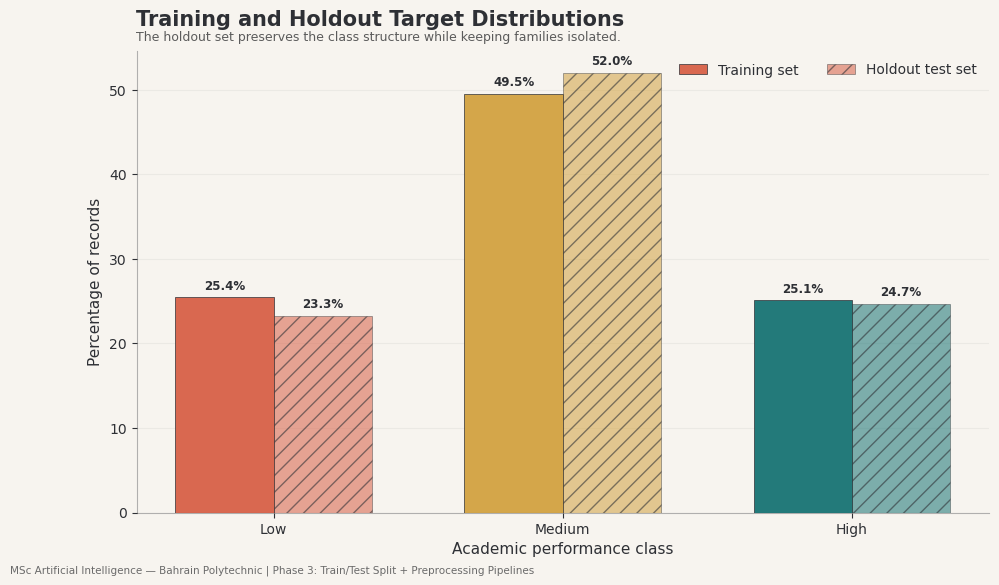

In [15]:
# Cell 3.10.1 — Visualise Train and Holdout Target Distributions

CELL_FOLDERS = create_cell_folders(
    "03_10",
    "Multiple_Visualization_Experimental_Design",
    "03_10_01",
    "Visualise_Train_and_Holdout_Target_Distributions",
)

plot_distribution = split_distribution[
    split_distribution["dataset_split"].isin(
        ["Training set", "Holdout test set"]
    )
].copy()

figure, axis = plt.subplots(figsize=(11, 6))

x_positions = np.arange(len(TARGET_CLASSES))
bar_width = 0.34

for offset, (split_name, hatch) in enumerate(
    [
        ("Training set", None),
        ("Holdout test set", "//"),
    ]
):
    split_rows = (
        plot_distribution[
            plot_distribution["dataset_split"] == split_name
        ]
        .set_index("academic_performance_class")
        .reindex(TARGET_CLASSES)
    )
    values = split_rows["percentage"].to_numpy()

    bars = axis.bar(
        x_positions + (offset - 0.5) * bar_width,
        values,
        width=bar_width,
        label=split_name,
        color=[
            CLASS_COLORS[class_name]
            for class_name in TARGET_CLASSES
        ],
        alpha=1.0 if offset == 0 else 0.58,
        hatch=hatch,
        edgecolor=THEME["charcoal"],
        linewidth=0.5,
    )

    for bar, value in zip(bars, values):
        axis.text(
            bar.get_x() + bar.get_width() / 2,
            value + 0.6,
            f"{value:.1f}%",
            ha="center",
            va="bottom",
            fontsize=8.5,
            fontweight="bold",
        )

style_axis(
    axis,
    "Training and Holdout Target Distributions",
    "The holdout set preserves the class structure while keeping families isolated.",
)
axis.set_xticks(x_positions)
axis.set_xticklabels(TARGET_CLASSES)
axis.set_xlabel("Academic performance class")
axis.set_ylabel("Percentage of records")
axis.legend(ncol=2, loc="upper right")
add_figure_footer(figure)
save_figure(
    figure,
    CELL_FOLDERS,
    "03_10_01_train_test_target_distribution",
)
plt.show()

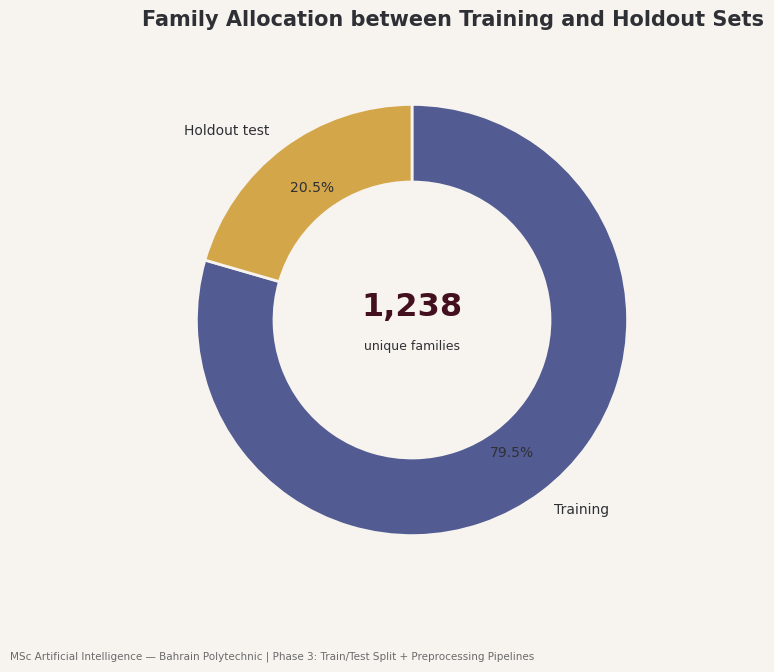

[WindowsPath('C:/Users/User/Desktop/All/outputs/Phase_03_Train_Test_Split_and_Preprocessing_Pipelines/Section_03_10_Multiple_Visualization_Experimental_Design/Cell_03_10_02_Visualise_Family_Allocation_and_Group_Sizes/tables/03_10_02_family_size_distribution.csv'),
 WindowsPath('C:/Users/User/Desktop/All/outputs/Phase_03_Train_Test_Split_and_Preprocessing_Pipelines/Section_03_10_Multiple_Visualization_Experimental_Design/Cell_03_10_02_Visualise_Family_Allocation_and_Group_Sizes/tables/03_10_02_family_size_distribution.xlsx')]

In [16]:
# Cell 3.10.2 — Visualise Family Allocation and Group Sizes

CELL_FOLDERS = create_cell_folders(
    "03_10",
    "Multiple_Visualization_Experimental_Design",
    "03_10_02",
    "Visualise_Family_Allocation_and_Group_Sizes",
)

family_allocation = pd.DataFrame(
    {
        "dataset_split": ["Training", "Holdout test"],
        "families": [
            groups_train.nunique(),
            groups_test.nunique(),
        ],
    }
)

figure, axis = plt.subplots(figsize=(8, 7))
axis.pie(
    family_allocation["families"],
    labels=family_allocation["dataset_split"],
    colors=[THEME["indigo"], THEME["gold"]],
    startangle=90,
    counterclock=False,
    autopct=lambda value: f"{value:.1f}%",
    pctdistance=0.77,
    wedgeprops={
        "width": 0.36,
        "edgecolor": THEME["warm_white"],
        "linewidth": 2,
    },
)
axis.text(
    0,
    0.06,
    f"{groups.nunique():,}",
    ha="center",
    va="center",
    fontsize=23,
    fontweight="bold",
    color=THEME["deep_maroon"],
)
axis.text(
    0,
    -0.12,
    "unique families",
    ha="center",
    va="center",
    fontsize=9,
)
axis.set_title(
    "Family Allocation between Training and Holdout Sets",
    loc="left",
    pad=18,
    fontweight="bold",
)
add_figure_footer(figure)
save_figure(
    figure,
    CELL_FOLDERS,
    "03_10_02_family_allocation_donut",
)
plt.show()

training_family_sizes = groups_train.value_counts().sort_index()
test_family_sizes = groups_test.value_counts().sort_index()

family_size_distribution = pd.DataFrame(
    {
        "student_records_per_family": sorted(
            set(training_family_sizes.unique())
            | set(test_family_sizes.unique())
        )
    }
)

family_size_distribution["training_families"] = (
    family_size_distribution["student_records_per_family"]
    .map(training_family_sizes.value_counts())
    .fillna(0)
    .astype(int)
)
family_size_distribution["test_families"] = (
    family_size_distribution["student_records_per_family"]
    .map(test_family_sizes.value_counts())
    .fillna(0)
    .astype(int)
)

save_dataframe(
    family_allocation,
    CELL_FOLDERS,
    "03_10_02_family_allocation",
)
save_dataframe(
    family_size_distribution,
    CELL_FOLDERS,
    "03_10_02_family_size_distribution",
)

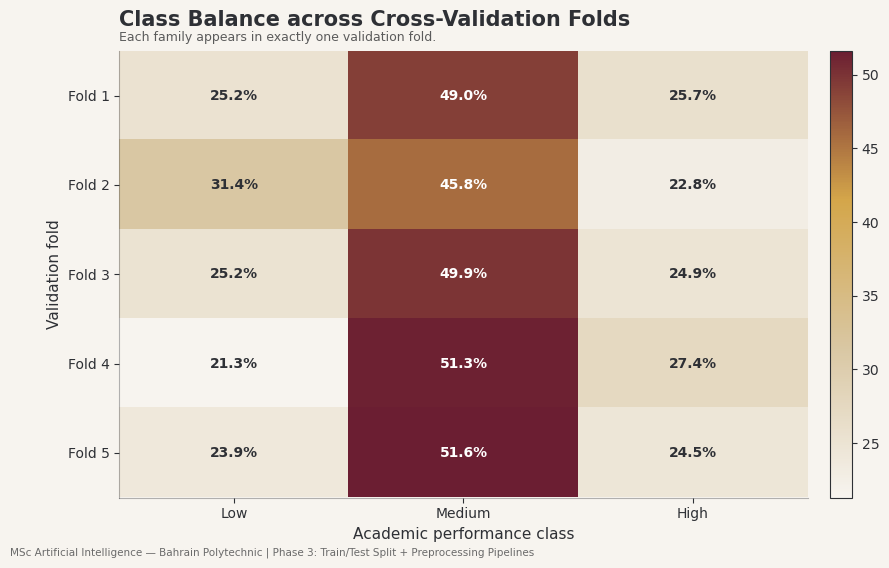

In [17]:
# Cell 3.10.3 — Visualise Cross-Validation Fold Balance

CELL_FOLDERS = create_cell_folders(
    "03_10",
    "Multiple_Visualization_Experimental_Design",
    "03_10_03",
    "Visualise_Cross_Validation_Fold_Balance",
)

cv_heatmap_data = cv_fold_summary.set_index("fold")[
    [
        "validation_low_pct",
        "validation_medium_pct",
        "validation_high_pct",
    ]
].copy()
cv_heatmap_data.columns = ["Low", "Medium", "High"]

figure, axis = plt.subplots(figsize=(9.5, 5.8))

heatmap_values = cv_heatmap_data.to_numpy()
heatmap = axis.imshow(
    heatmap_values,
    aspect="auto",
    cmap=LinearSegmentedColormap.from_list(
        "cv_theme",
        [
            THEME["warm_white"],
            THEME["sand"],
            THEME["gold"],
            THEME["maroon"],
        ],
    ),
)

axis.set_xticks(np.arange(len(TARGET_CLASSES)))
axis.set_xticklabels(TARGET_CLASSES)
axis.set_yticks(np.arange(len(cv_heatmap_data)))
axis.set_yticklabels(
    [f"Fold {fold}" for fold in cv_heatmap_data.index]
)

for row_index in range(heatmap_values.shape[0]):
    for column_index in range(heatmap_values.shape[1]):
        value = heatmap_values[row_index, column_index]
        axis.text(
            column_index,
            row_index,
            f"{value:.1f}%",
            ha="center",
            va="center",
            fontweight="bold",
            color=(
                "white"
                if value > heatmap_values.max() * 0.72
                else THEME["charcoal"]
            ),
        )

style_axis(
    axis,
    "Class Balance across Cross-Validation Folds",
    "Each family appears in exactly one validation fold.",
    grid_axis=None,
)
axis.set_xlabel("Academic performance class")
axis.set_ylabel("Validation fold")
figure.colorbar(heatmap, ax=axis, fraction=0.035, pad=0.03)
add_figure_footer(figure)
save_figure(
    figure,
    CELL_FOLDERS,
    "03_10_03_cv_fold_balance_heatmap",
)
plt.show()

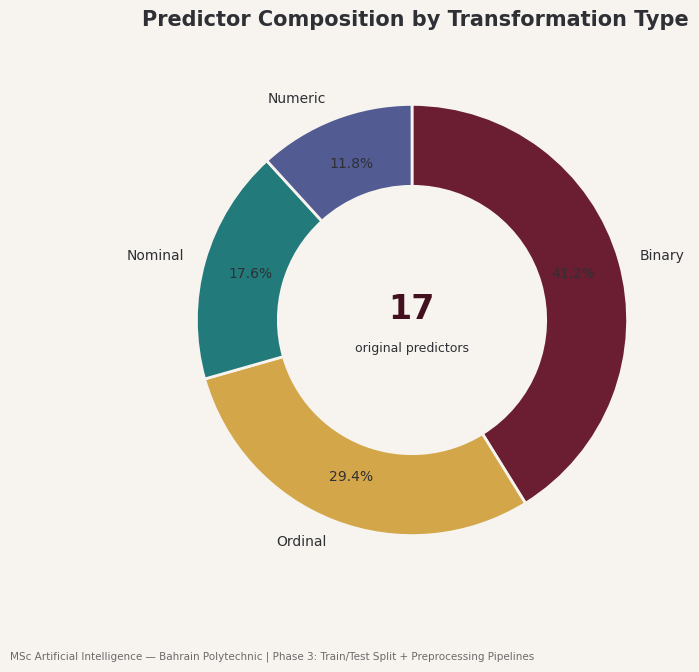

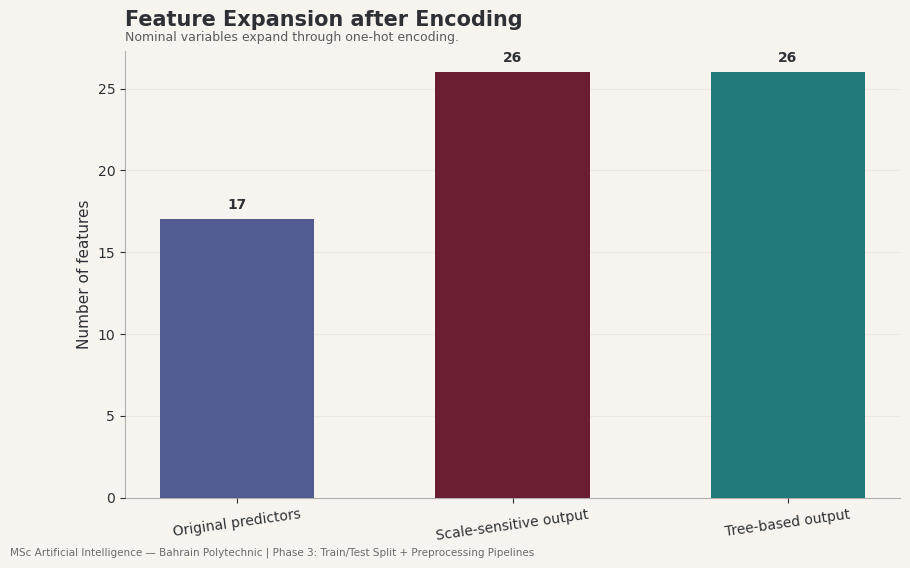

[WindowsPath('C:/Users/User/Desktop/All/outputs/Phase_03_Train_Test_Split_and_Preprocessing_Pipelines/Section_03_10_Multiple_Visualization_Experimental_Design/Cell_03_10_04_Visualise_Feature_Type_Composition_and_Transformation_Expansion/tables/03_10_04_transformation_expansion.csv'),
 WindowsPath('C:/Users/User/Desktop/All/outputs/Phase_03_Train_Test_Split_and_Preprocessing_Pipelines/Section_03_10_Multiple_Visualization_Experimental_Design/Cell_03_10_04_Visualise_Feature_Type_Composition_and_Transformation_Expansion/tables/03_10_04_transformation_expansion.xlsx')]

In [18]:
# Cell 3.10.4 — Visualise Feature-Type Composition and Transformation Expansion

CELL_FOLDERS = create_cell_folders(
    "03_10",
    "Multiple_Visualization_Experimental_Design",
    "03_10_04",
    "Visualise_Feature_Type_Composition_and_Transformation_Expansion",
)

feature_type_counts = (
    feature_group_table["feature_group"]
    .value_counts()
    .reindex(["Binary", "Ordinal", "Nominal", "Numeric"])
    .rename_axis("feature_group")
    .reset_index(name="feature_count")
)

figure, axis = plt.subplots(figsize=(8, 7))
axis.pie(
    feature_type_counts["feature_count"],
    labels=feature_type_counts["feature_group"],
    colors=[
        THEME["maroon"],
        THEME["gold"],
        THEME["teal"],
        THEME["indigo"],
    ],
    startangle=90,
    counterclock=False,
    autopct=lambda value: f"{value:.1f}%",
    pctdistance=0.78,
    wedgeprops={
        "width": 0.38,
        "edgecolor": THEME["warm_white"],
        "linewidth": 2,
    },
)
axis.text(
    0,
    0.05,
    f"{len(PREDICTOR_COLUMNS)}",
    ha="center",
    va="center",
    fontsize=24,
    fontweight="bold",
    color=THEME["deep_maroon"],
)
axis.text(
    0,
    -0.13,
    "original predictors",
    ha="center",
    va="center",
    fontsize=9,
)
axis.set_title(
    "Predictor Composition by Transformation Type",
    loc="left",
    pad=18,
    fontweight="bold",
)
add_figure_footer(figure)
save_figure(
    figure,
    CELL_FOLDERS,
    "03_10_04_feature_type_donut",
)
plt.show()

transformation_expansion = pd.DataFrame(
    {
        "stage": [
            "Original predictors",
            "Scale-sensitive output",
            "Tree-based output",
        ],
        "feature_count": [
            len(PREDICTOR_COLUMNS),
            len(scale_feature_names),
            len(tree_feature_names),
        ],
    }
)

figure, axis = plt.subplots(figsize=(10, 5.8))
bars = axis.bar(
    transformation_expansion["stage"],
    transformation_expansion["feature_count"],
    color=[
        THEME["indigo"],
        THEME["maroon"],
        THEME["teal"],
    ],
    width=0.56,
)

for bar, value in zip(
    bars,
    transformation_expansion["feature_count"],
):
    axis.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.45,
        str(int(value)),
        ha="center",
        va="bottom",
        fontweight="bold",
    )

style_axis(
    axis,
    "Feature Expansion after Encoding",
    "Nominal variables expand through one-hot encoding.",
)
axis.set_ylabel("Number of features")
axis.tick_params(axis="x", rotation=8)
add_figure_footer(figure)
save_figure(
    figure,
    CELL_FOLDERS,
    "03_10_04_transformation_expansion",
)
plt.show()

save_dataframe(
    feature_type_counts,
    CELL_FOLDERS,
    "03_10_04_feature_type_counts",
)
save_dataframe(
    transformation_expansion,
    CELL_FOLDERS,
    "03_10_04_transformation_expansion",
)

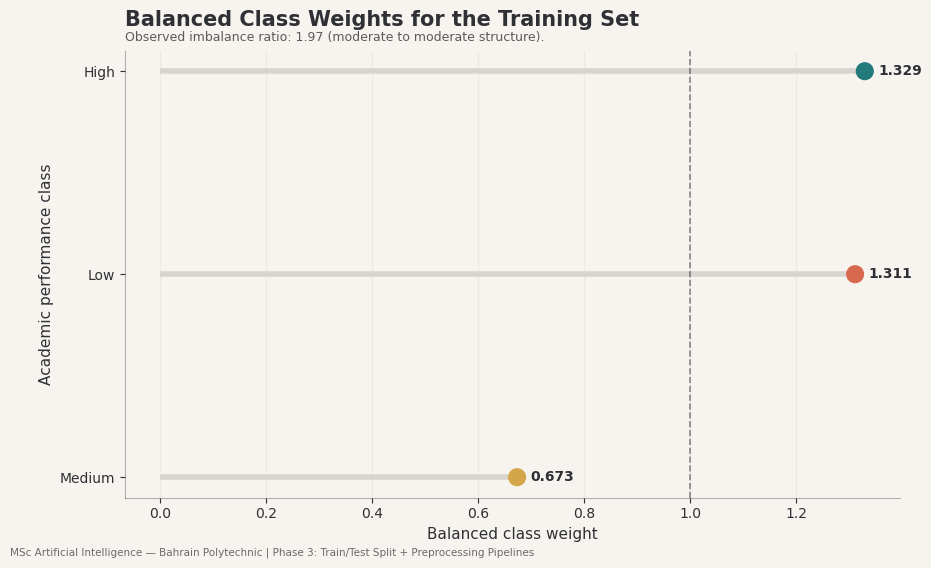

In [19]:
# Cell 3.10.5 — Visualise Class Imbalance and Balanced Weights

CELL_FOLDERS = create_cell_folders(
    "03_10",
    "Multiple_Visualization_Experimental_Design",
    "03_10_05",
    "Visualise_Class_Imbalance_and_Balanced_Weights",
)

plot_data = class_imbalance_table.sort_values(
    "balanced_class_weight",
    ascending=True,
)

figure, axis = plt.subplots(figsize=(10, 5.8))
axis.hlines(
    y=plot_data["academic_performance_class"],
    xmin=0,
    xmax=plot_data["balanced_class_weight"],
    color=THEME["soft_grey"],
    linewidth=4,
)
axis.scatter(
    plot_data["balanced_class_weight"],
    plot_data["academic_performance_class"],
    s=145,
    color=[
        CLASS_COLORS[class_name]
        for class_name in plot_data["academic_performance_class"]
    ],
    zorder=3,
)

for _, row in plot_data.iterrows():
    axis.text(
        row["balanced_class_weight"] + 0.025,
        row["academic_performance_class"],
        f"{row['balanced_class_weight']:.3f}",
        va="center",
        fontweight="bold",
    )

axis.axvline(
    1.0,
    color=THEME["charcoal"],
    linestyle="--",
    linewidth=1.2,
    alpha=0.55,
)

style_axis(
    axis,
    "Balanced Class Weights for the Training Set",
    (
        f"Observed imbalance ratio: {imbalance_ratio:.2f} "
        f"({imbalance_level.lower()} to moderate structure)."
    ),
    grid_axis="x",
)
axis.set_xlabel("Balanced class weight")
axis.set_ylabel("Academic performance class")
add_figure_footer(figure)
save_figure(
    figure,
    CELL_FOLDERS,
    "03_10_05_balanced_class_weights_lollipop",
)
plt.show()

In [20]:
# Cell 3.10.6 — Create the Phase 3 Visualisation Catalogue

CELL_FOLDERS = create_cell_folders(
    "03_10",
    "Multiple_Visualization_Experimental_Design",
    "03_10_06",
    "Create_the_Phase_3_Visualisation_Catalogue",
)

figure_files = sorted(PHASE_DIR.rglob("*.png"))

visualisation_catalogue = pd.DataFrame(
    [
        {
            "figure_number": number,
            "figure_name": path.stem,
            "relative_path": str(path.relative_to(PHASE_DIR)),
            "file_size_kb": round(path.stat().st_size / 1024, 2),
        }
        for number, path in enumerate(figure_files, start=1)
    ]
)

save_dataframe(
    visualisation_catalogue,
    CELL_FOLDERS,
    "03_10_06_visualisation_catalogue",
)

print("Phase 3 figures:", len(visualisation_catalogue))
display(visualisation_catalogue)

Phase 3 figures: 6


,figure_number,figure_name,relative_path,file_size_kb
0,1,03_10_01_train_test_target_distribution,Section_03_10_Multiple_Visualization_Experimen...,201.34
1,2,03_10_02_family_allocation_donut,Section_03_10_Multiple_Visualization_Experimen...,153.31
2,3,03_10_03_cv_fold_balance_heatmap,Section_03_10_Multiple_Visualization_Experimen...,202.32
3,4,03_10_04_feature_type_donut,Section_03_10_Multiple_Visualization_Experimen...,161.74
4,5,03_10_04_transformation_expansion,Section_03_10_Multiple_Visualization_Experimen...,159.05
5,6,03_10_05_balanced_class_weights_lollipop,Section_03_10_Multiple_Visualization_Experimen...,151.23


# Section 3.11 — Export Multiple Files and Phase Handoff

**Purpose:** Save the raw training and untouched test partitions, fold assignments, reusable preprocessing templates, experimental configuration, consolidated reports, and the Phase 4 handoff package.

In [21]:
# Cell 3.11.1 — Export Training, Holdout, Target, Group, and ID Files

CELL_FOLDERS = create_cell_folders(
    "03_11",
    "Export_Multiple_Files_and_Phase_Handoff",
    "03_11_01",
    "Export_Training_Holdout_Target_Group_and_ID_Files",
)

train_dataset = pd.concat(
    [
        record_ids_train.rename(ID_COLUMN),
        groups_train.rename(GROUP_COLUMN),
        X_train,
        y_train.rename(TARGET_COLUMN),
    ],
    axis=1,
)

test_dataset = pd.concat(
    [
        record_ids_test.rename(ID_COLUMN),
        groups_test.rename(GROUP_COLUMN),
        X_test,
        y_test.rename(TARGET_COLUMN),
    ],
    axis=1,
)

FINAL_TRAIN_CSV = DATA_DIR / "phase_03_training_dataset_for_phase_04.csv"
FINAL_TRAIN_XLSX = DATA_DIR / "phase_03_training_dataset_for_phase_04.xlsx"

FINAL_TEST_CSV = DATA_DIR / "phase_03_untouched_holdout_test_for_phase_08.csv"
FINAL_TEST_XLSX = DATA_DIR / "phase_03_untouched_holdout_test_for_phase_08.xlsx"

X_TRAIN_CSV = DATA_DIR / "phase_03_X_train.csv"
Y_TRAIN_CSV = DATA_DIR / "phase_03_y_train.csv"
GROUPS_TRAIN_CSV = DATA_DIR / "phase_03_groups_train.csv"

X_TEST_CSV = DATA_DIR / "phase_03_X_test_untouched.csv"
Y_TEST_CSV = DATA_DIR / "phase_03_y_test_untouched.csv"
GROUPS_TEST_CSV = DATA_DIR / "phase_03_groups_test_untouched.csv"

train_dataset.to_csv(
    FINAL_TRAIN_CSV,
    index=False,
    encoding="utf-8-sig",
)
train_dataset.to_excel(
    FINAL_TRAIN_XLSX,
    index=False,
)

test_dataset.to_csv(
    FINAL_TEST_CSV,
    index=False,
    encoding="utf-8-sig",
)
test_dataset.to_excel(
    FINAL_TEST_XLSX,
    index=False,
)

X_train.to_csv(X_TRAIN_CSV, index=False, encoding="utf-8-sig")
y_train.to_frame(TARGET_COLUMN).to_csv(
    Y_TRAIN_CSV,
    index=False,
    encoding="utf-8-sig",
)
groups_train.to_frame(GROUP_COLUMN).to_csv(
    GROUPS_TRAIN_CSV,
    index=False,
    encoding="utf-8-sig",
)

X_test.to_csv(X_TEST_CSV, index=False, encoding="utf-8-sig")
y_test.to_frame(TARGET_COLUMN).to_csv(
    Y_TEST_CSV,
    index=False,
    encoding="utf-8-sig",
)
groups_test.to_frame(GROUP_COLUMN).to_csv(
    GROUPS_TEST_CSV,
    index=False,
    encoding="utf-8-sig",
)

for source_path in [
    FINAL_TRAIN_CSV,
    FINAL_TRAIN_XLSX,
    FINAL_TEST_CSV,
    FINAL_TEST_XLSX,
    X_TRAIN_CSV,
    Y_TRAIN_CSV,
    GROUPS_TRAIN_CSV,
    X_TEST_CSV,
    Y_TEST_CSV,
    GROUPS_TEST_CSV,
]:
    shutil.copy2(
        source_path,
        CELL_FOLDERS["files"] / source_path.name,
    )

dataset_export_summary = pd.DataFrame(
    [
        [
            "Training dataset for Phase 4",
            str(FINAL_TRAIN_CSV),
            len(train_dataset),
            len(train_dataset.columns),
            "Available for CV model development",
        ],
        [
            "Untouched holdout test for Phase 8",
            str(FINAL_TEST_CSV),
            len(test_dataset),
            len(test_dataset.columns),
            "Do not use for Phase 4 model selection",
        ],
    ],
    columns=[
        "dataset",
        "path",
        "records",
        "columns",
        "usage_policy",
    ],
)

save_dataframe(
    dataset_export_summary,
    CELL_FOLDERS,
    "03_11_01_dataset_export_summary",
)

display(dataset_export_summary)

,dataset,path,records,columns,usage_policy
0,Training dataset for Phase 4,C:\Users\User\Desktop\All\data\phase_03_traini...,2006,20,Available for CV model development
1,Untouched holdout test for Phase 8,C:\Users\User\Desktop\All\data\phase_03_untouc...,494,20,Do not use for Phase 4 model selection


In [22]:
# Cell 3.11.2 — Export Portable Pipelines, Fold Assignments, and Configuration

CELL_FOLDERS = create_cell_folders(
    "03_11",
    "Export_Multiple_Files_and_Phase_Handoff",
    "03_11_02",
    "Export_Portable_Pipelines_Fold_Assignments_and_Configuration",
)

PORTABLE_SCALE_PREPROCESSOR = (
    SHARED_DIR / "phase_03_scale_sensitive_preprocessor_unfitted.joblib"
)
PORTABLE_TREE_PREPROCESSOR = (
    SHARED_DIR / "phase_03_tree_based_preprocessor_unfitted.joblib"
)
PORTABLE_CROSS_VALIDATOR = (
    SHARED_DIR / "phase_03_stratified_group_cross_validator.joblib"
)

joblib.dump(
    scale_sensitive_preprocessor,
    PORTABLE_SCALE_PREPROCESSOR,
)
joblib.dump(
    tree_based_preprocessor,
    PORTABLE_TREE_PREPROCESSOR,
)
joblib.dump(
    cross_validator,
    PORTABLE_CROSS_VALIDATOR,
)

CV_ASSIGNMENT_CSV = DATA_DIR / "phase_03_cross_validation_folds.csv"
HOLDOUT_ASSIGNMENT_CSV = DATA_DIR / "phase_03_holdout_split_assignment.csv"

cv_assignment.to_csv(
    CV_ASSIGNMENT_CSV,
    index=False,
    encoding="utf-8-sig",
)
holdout_assignment.to_csv(
    HOLDOUT_ASSIGNMENT_CSV,
    index=False,
    encoding="utf-8-sig",
)

for source_path in [
    PORTABLE_SCALE_PREPROCESSOR,
    PORTABLE_TREE_PREPROCESSOR,
    PORTABLE_CROSS_VALIDATOR,
    CV_ASSIGNMENT_CSV,
    HOLDOUT_ASSIGNMENT_CSV,
]:
    shutil.copy2(
        source_path,
        CELL_FOLDERS["files"] / source_path.name,
    )

experimental_configuration = {
    "random_state": RANDOM_STATE,
    "test_size_requested": TEST_SIZE,
    "test_size_observed": len(X_test) / len(X),
    "selected_holdout_candidate": selected_candidate_number,
    "holdout_method": "StratifiedGroupKFold candidate fold",
    "cv_method": "StratifiedGroupKFold",
    "cv_folds": CV_FOLDS,
    "identifier_column": ID_COLUMN,
    "group_column": GROUP_COLUMN,
    "target_column": TARGET_COLUMN,
    "predictor_columns": PREDICTOR_COLUMNS,
    "binary_columns": BINARY_COLUMNS,
    "ordinal_columns": ORDINAL_COLUMNS,
    "nominal_columns": NOMINAL_COLUMNS,
    "numeric_columns": NUMERIC_COLUMNS,
    "target_classes": TARGET_CLASSES,
    "class_weights": balanced_class_weights,
    "primary_metric": "f1_macro",
    "holdout_final_evaluation_phase": 8,
}

EXPERIMENT_CONFIG_PATH = save_json_report(
    experimental_configuration,
    CELL_FOLDERS,
    "03_11_02_experimental_configuration",
)

print("Portable scale-sensitive preprocessor:", PORTABLE_SCALE_PREPROCESSOR)
print("Portable tree-based preprocessor:", PORTABLE_TREE_PREPROCESSOR)
print("Cross-validation assignment:", CV_ASSIGNMENT_CSV)

Portable scale-sensitive preprocessor: C:\Users\User\Desktop\All\shared_project_files\phase_03_scale_sensitive_preprocessor_unfitted.joblib
Portable tree-based preprocessor: C:\Users\User\Desktop\All\shared_project_files\phase_03_tree_based_preprocessor_unfitted.joblib
Cross-validation assignment: C:\Users\User\Desktop\All\data\phase_03_cross_validation_folds.csv


In [23]:
# Cell 3.11.3 — Export the Consolidated Phase 3 Workbook

CELL_FOLDERS = create_cell_folders(
    "03_11",
    "Export_Multiple_Files_and_Phase_Handoff",
    "03_11_03",
    "Export_the_Consolidated_Phase_3_Workbook",
)

CONSOLIDATED_WORKBOOK_PATH = (
    CELL_FOLDERS["files"]
    / "03_11_03_phase_3_consolidated_reports.xlsx"
)

workbook_tables = {
    "Project_Config": pd.DataFrame([project_configuration]),
    "Library_Versions": library_versions,
    "Variable_Roles": role_table,
    "Holdout_Candidates": holdout_candidate_table,
    "Holdout_Validation": holdout_validation,
    "Split_Distribution": split_distribution,
    "Holdout_Assignment": holdout_assignment,
    "CV_Fold_Summary": cv_fold_summary,
    "CV_Validation": cv_validation,
    "CV_Assignment": cv_assignment,
    "Feature_Groups": feature_group_table,
    "Scaling_Strategy": scaling_strategy,
    "Pipeline_Structure": pipeline_structure,
    "Pipeline_Audit": pipeline_audit_summary,
    "Scale_Features": scale_feature_table,
    "Tree_Features": tree_feature_table,
    "Class_Imbalance": class_imbalance_table,
    "Evaluation_Metrics": evaluation_metric_table,
    "Visual_Catalogue": visualisation_catalogue,
    "Dataset_Exports": dataset_export_summary,
}

with pd.ExcelWriter(
    CONSOLIDATED_WORKBOOK_PATH,
    engine="openpyxl",
) as writer:
    for sheet_name, dataframe in workbook_tables.items():
        dataframe.to_excel(
            writer,
            sheet_name=sheet_name[:31],
            index=False,
        )

print("Consolidated workbook:", CONSOLIDATED_WORKBOOK_PATH)

Consolidated workbook: C:\Users\User\Desktop\All\outputs\Phase_03_Train_Test_Split_and_Preprocessing_Pipelines\Section_03_11_Export_Multiple_Files_and_Phase_Handoff\Cell_03_11_03_Export_the_Consolidated_Phase_3_Workbook\files\03_11_03_phase_3_consolidated_reports.xlsx


In [24]:
# Cell 3.11.4 — Create Quality Checks, Phase 4 Handoff, and ZIP Archive

CELL_FOLDERS = create_cell_folders(
    "03_11",
    "Export_Multiple_Files_and_Phase_Handoff",
    "03_11_04",
    "Create_Quality_Checks_Phase_4_Handoff_and_ZIP_Archive",
)

quality_checks = []


def add_quality_check(name, passed, details):
    quality_checks.append(
        {
            "quality_check": name,
            "passed": bool(passed),
            "details": str(details),
        }
    )


add_quality_check(
    "No family overlap between training and holdout",
    len(set(groups_train).intersection(set(groups_test))) == 0,
    len(set(groups_train).intersection(set(groups_test))),
)

add_quality_check(
    "All training records assigned to one CV validation fold",
    cv_assignment["validation_fold"].notna().all(),
    cv_assignment["validation_fold"].value_counts().to_dict(),
)

add_quality_check(
    "No family overlap within any CV fold",
    cv_validation["family_overlap_is_zero"].all(),
    cv_validation.to_dict(orient="records"),
)

add_quality_check(
    "All target classes available in every CV validation fold",
    cv_validation["all_classes_in_validation"].all(),
    cv_fold_summary[
        [
            "fold",
            "validation_low_pct",
            "validation_medium_pct",
            "validation_high_pct",
        ]
    ].to_dict(orient="records"),
)

add_quality_check(
    "Unfitted preprocessing templates saved",
    (
        PORTABLE_SCALE_PREPROCESSOR.exists()
        and PORTABLE_TREE_PREPROCESSOR.exists()
    ),
    [
        str(PORTABLE_SCALE_PREPROCESSOR),
        str(PORTABLE_TREE_PREPROCESSOR),
    ],
)

add_quality_check(
    "Holdout test exported separately",
    FINAL_TEST_CSV.exists(),
    str(FINAL_TEST_CSV),
)

add_quality_check(
    "Training and test records cover the complete Phase 2 dataset",
    len(train_dataset) + len(test_dataset) == len(modelling_data),
    (
        f"{len(train_dataset)} + {len(test_dataset)} "
        f"= {len(modelling_data)}"
    ),
)

phase_3_quality_checks = pd.DataFrame(quality_checks)

save_dataframe(
    phase_3_quality_checks,
    CELL_FOLDERS,
    "03_11_04_phase_3_quality_checks",
)
save_json_report(
    quality_checks,
    CELL_FOLDERS,
    "03_11_04_phase_3_quality_checks",
)

if not phase_3_quality_checks["passed"].all():
    failed = phase_3_quality_checks.loc[
        ~phase_3_quality_checks["passed"],
        "quality_check",
    ].tolist()
    raise AssertionError(
        "Phase 3 quality checks failed: " + "; ".join(failed)
    )

phase_4_handoff = {
    "completed_phase": "Phase 3 — Train/Test Split + Preprocessing Pipelines",
    "next_phase": "Phase 4 — Supervised Learning Algorithms",
    "data_source": phase_2_manifest.get("data_source", "UNKNOWN"),
    "primary_training_dataset_for_phase_4": str(FINAL_TRAIN_CSV),
    "alternative_training_excel": str(FINAL_TRAIN_XLSX),
    "X_train": str(X_TRAIN_CSV),
    "y_train": str(Y_TRAIN_CSV),
    "groups_train": str(GROUPS_TRAIN_CSV),
    "cross_validation_fold_assignment": str(CV_ASSIGNMENT_CSV),
    "holdout_split_assignment": str(HOLDOUT_ASSIGNMENT_CSV),
    "scale_sensitive_preprocessor": str(PORTABLE_SCALE_PREPROCESSOR),
    "tree_based_preprocessor": str(PORTABLE_TREE_PREPROCESSOR),
    "cross_validator": str(PORTABLE_CROSS_VALIDATOR),
    "untouched_holdout_test_for_phase_8": str(FINAL_TEST_CSV),
    "X_test_untouched": str(X_TEST_CSV),
    "y_test_untouched": str(Y_TEST_CSV),
    "groups_test_untouched": str(GROUPS_TEST_CSV),
    "training_records": int(len(X_train)),
    "holdout_records": int(len(X_test)),
    "training_families": int(groups_train.nunique()),
    "holdout_families": int(groups_test.nunique()),
    "family_overlap": 0,
    "identifier_column": ID_COLUMN,
    "group_column": GROUP_COLUMN,
    "target_column": TARGET_COLUMN,
    "predictor_columns": PREDICTOR_COLUMNS,
    "target_classes": TARGET_CLASSES,
    "class_weights": balanced_class_weights,
    "primary_metric": "f1_macro",
    "cv_folds": CV_FOLDS,
    "random_state": RANDOM_STATE,
    "phase_4_must_not_use_holdout_for_model_selection": True,
    "final_holdout_evaluation_phase": 8,
    "phase_2_input_sha256": INPUT_FILE_SHA256,
    "training_dataset_sha256": sha256_file(FINAL_TRAIN_CSV),
    "holdout_dataset_sha256": sha256_file(FINAL_TEST_CSV),
    "quality_checks_passed": True,
    "generated_at": datetime.now().isoformat(),
}

PHASE_4_HANDOFF_PATH = save_json_report(
    phase_4_handoff,
    CELL_FOLDERS,
    "phase_03_handoff_manifest_for_phase_04",
)

# Portable root copy for automatic Phase 4 discovery.
with (PHASE_DIR / "phase_03_handoff_manifest_for_phase_04.json").open(
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        phase_4_handoff,
        file,
        ensure_ascii=False,
        indent=2,
    )

summary_text = f"""
PHASE 3 COMPLETION SUMMARY
{'=' * 76}

Project:
{PROJECT_TITLE}

Student:
{STUDENT_NAME} | ID: {STUDENT_ID}

Phase 2 input:
{PHASE_2_DATA_PATH}

Split:
- Training records: {len(X_train):,}
- Holdout test records: {len(X_test):,}
- Training families: {groups_train.nunique():,}
- Holdout families: {groups_test.nunique():,}
- Family overlap: 0

Cross-validation:
- Method: StratifiedGroupKFold
- Folds: {CV_FOLDS}
- Training data only: True

Preprocessing:
- Scale-sensitive template: {PORTABLE_SCALE_PREPROCESSOR}
- Tree-based template: {PORTABLE_TREE_PREPROCESSOR}
- Templates saved unfitted: True

Class imbalance:
- Ratio: {imbalance_ratio:.3f}
- Level: {imbalance_level}
- Primary metric: Macro F1

Holdout policy:
The holdout test set is protected from Phase 4 model selection and is
reserved for the final evaluation in Phase 8.
""".strip()

summary_path = (
    CELL_FOLDERS["reports"]
    / "03_11_04_phase_3_summary.txt"
)
summary_path.write_text(summary_text, encoding="utf-8")

ZIP_PATH = (
    CELL_FOLDERS["files"]
    / "03_11_04_phase_3_complete_export.zip"
)

with zipfile.ZipFile(
    ZIP_PATH,
    mode="w",
    compression=zipfile.ZIP_DEFLATED,
) as zip_file:
    for file_path in sorted(PHASE_DIR.rglob("*")):
        if not file_path.is_file() or file_path == ZIP_PATH:
            continue
        zip_file.write(
            file_path,
            file_path.relative_to(PHASE_DIR),
        )

display(phase_3_quality_checks)
print(summary_text)
print("\nPhase 4 handoff:", PHASE_4_HANDOFF_PATH)
print("Complete ZIP:", ZIP_PATH)

,quality_check,passed,details
0,No family overlap between training and holdout,True,0
1,All training records assigned to one CV valida...,True,"{np.int64(3): 413, np.int64(4): 413, np.int64(..."
2,No family overlap within any CV fold,True,"[{'fold': 1, 'family_overlap_is_zero': True, '..."
3,All target classes available in every CV valid...,True,"[{'fold': 1, 'validation_low_pct': 25.248, 'va..."
4,Unfitted preprocessing templates saved,True,['C:\\Users\\User\\Desktop\\All\\shared_projec...
5,Holdout test exported separately,True,C:\Users\User\Desktop\All\data\phase_03_untouc...
6,Training and test records cover the complete P...,True,2006 + 494 = 2500


PHASE 3 COMPLETION SUMMARY

Project:
Design a Machine Learning Approach to Analyse Students’ Performance Based on Their Socio-economic Status in the Kingdom of Bahrain

Student:
Jaafar Ahmed | ID: 202508989

Phase 2 input:
C:\Users\User\Desktop\All\data\phase_02_modelling_dataset_for_phase_03.csv

Split:
- Training records: 2,006
- Holdout test records: 494
- Training families: 984
- Holdout families: 254
- Family overlap: 0

Cross-validation:
- Method: StratifiedGroupKFold
- Folds: 5
- Training data only: True

Preprocessing:
- Scale-sensitive template: C:\Users\User\Desktop\All\shared_project_files\phase_03_scale_sensitive_preprocessor_unfitted.joblib
- Tree-based template: C:\Users\User\Desktop\All\shared_project_files\phase_03_tree_based_preprocessor_unfitted.joblib
- Templates saved unfitted: True

Class imbalance:
- Ratio: 1.974
- Level: Moderate
- Primary metric: Macro F1

Holdout policy:
The holdout test set is protected from Phase 4 model selection and is
reserved for the fina

# Phase 3 Completed

Phase 3 produces a family-aware experimental design with an untouched holdout test set, five cross-validation folds on the training data, and two reusable preprocessing templates.

```text
Phase 2 modelling dataset
        ↓
Stratified family-aware holdout split
        ↓
Training set → Phase 4 supervised model development
        ↓
Untouched holdout test → Phase 8 final evaluation
```